In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from sklearn.model_selection import StratifiedKFold
from datasets import Dataset
from transformers import EarlyStoppingCallback
from transformers import AutoModelForTokenClassification
from transformers import DataCollatorForTokenClassification
from transformers import Trainer
import matplotlib.pyplot as plt
import os
import gc
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    DataCollatorForTokenClassification,
)
from torch.utils.data import DataLoader
import pickle
import json

Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_synth=pd.read_json("/content/drive/MyDrive/Archimedes_Anonymization/pilot_with_faker.jsonl", lines=True)
df_orig=pd.read_pickle("/content/drive/MyDrive/Archimedes_Anonymization/df.pkl")

In [ ]:
df_synth=pd.read_json("/content/pilot_with_faker.jsonl", lines=True)
df_orig=pd.read_pickle("/content/df.pkl")

In [ ]:
# @title
# κρατάμε μόνο τις στήλες που χρειαζόμαστε
df_orig=df_orig.reset_index()
orig_df = df_orig[["index", "free_text", "gold_spans_free_text"]].copy()

orig_df = orig_df.rename(columns={
    "index": "original_idx",
    "free_text": "text",
    "gold_spans_free_text": "entities"
})

orig_df["source"] = "original"

#print(orig_df.shape)
#orig_df.head()

In [ ]:
# @title
def convert_orig_entities(spans):
    if not isinstance(spans, list):
        return []

    entities = []

    for span in spans:
        start, end, label = span

        if label == "hospital_name":
            label = "HOSPITAL"
        elif label == "person_name":
            label = "PERSON"

        entities.append({
            "start": start,
            "end": end,
            "label": label
        })

    return entities

orig_df["entities"] = orig_df["entities"].apply(convert_orig_entities)

In [ ]:
# @title
synth_df = df_synth[["original_idx", "synthetic_filled", "entities"]].copy()

synth_df = synth_df.rename(columns={
    "synthetic_filled": "text"
})

synth_df["source"] = "synthetic"

#print(synth_df.shape)
#synth_df.head()

In [ ]:
# @title
ALLOWED_ENTITY_TYPES = {"PERSON", "HOSPITAL"}

def filter_entities(entities):
    if not isinstance(entities, list):
        return []

    out = []
    for ent in entities:
        if not isinstance(ent, dict):
            continue
        if ent.get("label") not in ALLOWED_ENTITY_TYPES:
            continue

        out.append({
            "start": int(ent["start"]),
            "end": int(ent["end"]),
            "label": ent["label"]
        })
    return out

In [ ]:
# @title
orig_df["entities_model"] = orig_df["entities"].apply(filter_entities)
synth_df["entities_model"] = synth_df["entities"].apply(filter_entities)

In [ ]:
# @title
orig_final = orig_df[["original_idx", "text", "entities_model", "source"]].copy()
synth_final = synth_df[["original_idx", "text", "entities_model", "source"]].copy()

ner_df = pd.concat([orig_final, synth_final], ignore_index=True)

In [ ]:
ner_df

,original_idx,text,entities_model,source
0,0,ΑΙΤΙΑ ΕΙΣΟΔΟΥ – ΙΣΤΟΡΙΚΟ – ΠΟΡΕΙΑ ΝΟΣΟΥ\nΑτομι...,"[{'start': 298, 'end': 321, 'label': 'HOSPITAL...",original
1,1,ΑΙΤΙΑ ΕΙΣΟΔΟΥ – ΙΣΤΟΡΙΚΟ\n\nΠρογραμματισμένη ε...,"[{'start': 60, 'end': 90, 'label': 'HOSPITAL'}...",original
2,2,ΑΙΤΙΑ ΕΙΣΟΔΟΥ – ΙΣΤΟΡΙΚΟ\nΑιτία εισόδου: Ασθεν...,"[{'start': 792, 'end': 822, 'label': 'HOSPITAL'}]",original
3,3,ΑΙΤΙΑ ΕΙΣΟΔΟΥ – ΙΣΤΟΡΙΚΟ\nΑΙΤΙΑ ΕΙΣΟΔΟΥ:\nΟΠΟ-...,"[{'start': 953, 'end': 965, 'label': 'HOSPITAL'}]",original
4,4,ΑΙΤΙΑ ΕΙΣΟΔΟΥ – ΙΣΤΟΡΙΚΟ\nΑιτία εισόδου :Χειρο...,[],original
...,...,...,...,...
275,24,ΑΙΤΙΑ ΕΙΣΟΔΟΥ ΙΣΤΟΡΙΚΟ\n\nΟ ασθενής εισήχθη με...,[],synthetic
276,24,ΑΙΤΙΑ ΕΙΣΟΔΟΥ ΙΣΤΟΡΙΚΟ\n\nΟ ασθενής εισήχθη με...,[],synthetic
277,16,ΑΙΤΙΑ ΕΙΣΟΔΟΥ - ΙΣΤΟΡΙΚΟ\n\nΟ ασθενής εισήχθηκ...,"[{'start': 1520, 'end': 1530, 'label': 'PERSON...",synthetic
278,16,Η ΙΑΤΡΙΚΗ ΕΚΘΕΣΗ\n\nΑΙΤΙΑ ΕΙΣΟΔΟΥ - ΙΣΤΟΡΙΚΟ\n...,"[{'start': 1556, 'end': 1568, 'label': 'PERSON...",synthetic


In [ ]:
ner_df = ner_df.reset_index(drop=True).copy()
ner_df["instance_id"] = ner_df.index.astype(int)

In [ ]:
ner_df.groupby("original_idx")["instance_id"].count()

,instance_id
original_idx,
0,11
1,11
2,11
3,11
4,11
5,11
6,11
7,11
8,11


In [ ]:
ner_df

,original_idx,text,entities_model,source,instance_id
0,0,ΑΙΤΙΑ ΕΙΣΟΔΟΥ – ΙΣΤΟΡΙΚΟ – ΠΟΡΕΙΑ ΝΟΣΟΥ\nΑτομι...,"[{'start': 298, 'end': 321, 'label': 'HOSPITAL...",original,0
1,1,ΑΙΤΙΑ ΕΙΣΟΔΟΥ – ΙΣΤΟΡΙΚΟ\n\nΠρογραμματισμένη ε...,"[{'start': 60, 'end': 90, 'label': 'HOSPITAL'}...",original,1
2,2,ΑΙΤΙΑ ΕΙΣΟΔΟΥ – ΙΣΤΟΡΙΚΟ\nΑιτία εισόδου: Ασθεν...,"[{'start': 792, 'end': 822, 'label': 'HOSPITAL'}]",original,2
3,3,ΑΙΤΙΑ ΕΙΣΟΔΟΥ – ΙΣΤΟΡΙΚΟ\nΑΙΤΙΑ ΕΙΣΟΔΟΥ:\nΟΠΟ-...,"[{'start': 953, 'end': 965, 'label': 'HOSPITAL'}]",original,3
4,4,ΑΙΤΙΑ ΕΙΣΟΔΟΥ – ΙΣΤΟΡΙΚΟ\nΑιτία εισόδου :Χειρο...,[],original,4
...,...,...,...,...,...
275,24,ΑΙΤΙΑ ΕΙΣΟΔΟΥ ΙΣΤΟΡΙΚΟ\n\nΟ ασθενής εισήχθη με...,[],synthetic,275
276,24,ΑΙΤΙΑ ΕΙΣΟΔΟΥ ΙΣΤΟΡΙΚΟ\n\nΟ ασθενής εισήχθη με...,[],synthetic,276
277,16,ΑΙΤΙΑ ΕΙΣΟΔΟΥ - ΙΣΤΟΡΙΚΟ\n\nΟ ασθενής εισήχθηκ...,"[{'start': 1520, 'end': 1530, 'label': 'PERSON...",synthetic,277
278,16,Η ΙΑΤΡΙΚΗ ΕΚΘΕΣΗ\n\nΑΙΤΙΑ ΕΙΣΟΔΟΥ - ΙΣΤΟΡΙΚΟ\n...,"[{'start': 1556, 'end': 1568, 'label': 'PERSON...",synthetic,278


Split

In [ ]:
orig_df = ner_df[ner_df["source"] == "original"].copy()

doc_stats = (
    orig_df
    .groupby("original_idx")["entities_model"]
    .apply(lambda x: sum(len(e) for e in x))
    .reset_index(name="n_entities")
)

doc_stats["has_phi"] = (doc_stats["n_entities"] > 0).astype(int)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_rows = []

for fold_id, (_, test_idx) in enumerate(
    skf.split(doc_stats["original_idx"], doc_stats["has_phi"])
):
    test_docs = doc_stats.iloc[test_idx]["original_idx"].tolist()

    for doc_id in test_docs:
        fold_rows.append({
            "original_idx": doc_id,
            "fold": fold_id
        })

fold_df = pd.DataFrame(fold_rows).sort_values(
    ["fold", "original_idx"]
).reset_index(drop=True)

fold_df

,original_idx,fold
0,0,0
1,1,0
2,8,0
3,13,0
4,22,0
5,2,1
6,16,1
7,18,1
8,21,1
9,23,1


In [ ]:
EXPERIMENTS = {
#ola orig
    "orig_orig_orig": {
        "train": "original",
        "val": "original",
        "test": "original",
    },
#ola synth
    "syn_syn_syn": {
        "train": "synthetic",
        "val": "synthetic",
        "test": "synthetic",
    },
#synth -> orig
    "syn_orig_orig": {
        "train": "synthetic",
        "val": "original",
        "test": "original",
    },
#orig -> synth
    "orig_syn_syn": {
        "train": "original",
        "val": "synthetic",
        "test": "synthetic",
    },
#synth+orig ->synth

    "both_syn_syn": {
        "train": "both",
        "val": "synthetic",
        "test": "synthetic",
    },

    "both_orig_orig": {
        "train": "both",
        "val": "original",
        "test": "original",
    }
}

In [ ]:
def filter_by_source(df, source_mode):
    if source_mode == "original":
        return df[df["source"] == "original"].reset_index(drop=True)
    elif source_mode == "synthetic":
        return df[df["source"] == "synthetic"].reset_index(drop=True)
    elif source_mode == "both":
        return df.reset_index(drop=True)
    else:
        raise ValueError(f"Unknown source_mode: {source_mode}")

In [ ]:
from sklearn.model_selection import train_test_split

def get_doc_splits_for_fold(
    fold_id,
    fold_df,
    doc_stats,
    random_state=42,
    val_size=0.20,
):
    test_docs = fold_df.loc[
        fold_df["fold"] == fold_id, "original_idx"
    ].tolist()

    trainval_docs = fold_df.loc[
        fold_df["fold"] != fold_id, "original_idx"
    ].tolist()

    trainval_stats = doc_stats[
        doc_stats["original_idx"].isin(trainval_docs)
    ].copy()

    train_docs, val_docs = train_test_split(
        trainval_stats["original_idx"],
        test_size=val_size,
        random_state=random_state,
        stratify=trainval_stats["has_phi"]
    )

    train_docs = sorted([int(x) for x in train_docs.tolist()])
    val_docs = sorted([int(x) for x in val_docs.tolist()])
    test_docs = sorted([int(x) for x in test_docs])

    return train_docs, val_docs, test_docs

In [ ]:
def build_split_dfs_for_experiment(
    fold_id,
    fold_df,
    doc_stats,
    ner_df,
    experiment_name,
    random_state=42,
    val_size=0.20,
):
    cfg = EXPERIMENTS[experiment_name]

    train_docs, val_docs, test_docs = get_doc_splits_for_fold(
        fold_id=fold_id,
        fold_df=fold_df,
        doc_stats=doc_stats,
        random_state=random_state,
        val_size=val_size,
    )

    train_full = ner_df[
        ner_df["original_idx"].isin(train_docs)
    ].copy()

    val_full = ner_df[
        ner_df["original_idx"].isin(val_docs)
    ].copy()

    test_full = ner_df[
        ner_df["original_idx"].isin(test_docs)
    ].copy()

    train_df = filter_by_source(train_full, cfg["train"])
    val_df = filter_by_source(val_full, cfg["val"])
    test_df = filter_by_source(test_full, cfg["test"])



    return train_df, val_df, test_df, train_docs, val_docs, test_docs

In [ ]:
checkpoint = "Davlan/xlm-roberta-base-ner-hrl"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

label2id = {
    "O": 0,
    "B-PHI": 1,
    "I-PHI": 2,
}

id2label = {v: k for k, v in label2id.items()}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/980 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2
)

In [ ]:
def overlaps(span_a_start, span_a_end, span_b_start, span_b_end):
    return span_a_start < span_b_end and span_b_start < span_a_end

In [ ]:
def spans_to_bio_labels(offset_mapping, entities, label2id):
    labels = ["O"] * len(offset_mapping)

    for i, (tok_start, tok_end) in enumerate(offset_mapping):
        if tok_start == 0 and tok_end == 0:
            labels[i] = -100

    for ent in entities:
        ent_start = ent["start"]
        ent_end = ent["end"]

        overlapping_token_idxs = []

        for i, (tok_start, tok_end) in enumerate(offset_mapping):
            if tok_start == 0 and tok_end == 0:
                continue

            if overlaps(tok_start, tok_end, ent_start, ent_end):
                overlapping_token_idxs.append(i)

        if not overlapping_token_idxs:
            continue

        labels[overlapping_token_idxs[0]] = "B-PHI"

        for idx in overlapping_token_idxs[1:]:
            labels[idx] = "I-PHI"

    labels = [label2id[x] if x != -100 else -100 for x in labels]
    return labels

In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    true_preds = []
    true_labels = []

    for logit_seq, label_seq in zip(logits, labels):
        pred_seq = np.argmax(logit_seq, axis=-1)

        for p, l in zip(pred_seq, label_seq):
            if l == -100:
                continue
            true_preds.append(p)
            true_labels.append(l)

    true_preds = np.array(true_preds)
    true_labels = np.array(true_labels)

    pred_pos = np.isin(true_preds, [label2id["B-PHI"], label2id["I-PHI"]])
    true_pos = np.isin(true_labels, [label2id["B-PHI"], label2id["I-PHI"]])

    tp = np.sum(pred_pos & true_pos)
    fp = np.sum(pred_pos & ~true_pos)
    fn = np.sum(~pred_pos & true_pos)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return {
        "precision_phi": precision,
        "recall_phi": recall,
        "f1_phi": f1
    }

In [ ]:
def manual_predict(model, dataset_for_trainer, batch_size=8):
    loader = DataLoader(
        dataset_for_trainer,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=data_collator
    )

    model.eval()
    device = model.device

    all_logits = []
    all_labels = []

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.no_grad():
            outputs = model(**batch)

        batch_logits = outputs.logits.detach().cpu().numpy()
        batch_labels = batch["labels"].detach().cpu().numpy()

        for i in range(batch_logits.shape[0]):
            all_logits.append(batch_logits[i])
            all_labels.append(batch_labels[i])

    return all_logits, all_labels

In [ ]:
def build_hf_datasets(train_df, val_df, test_df):
    train_ds = Dataset.from_pandas(
        train_df[["instance_id","original_idx", "text", "entities_model", "source"]],
        preserve_index=False
    )
    val_ds = Dataset.from_pandas(
        val_df[["instance_id","original_idx", "text", "entities_model", "source"]],
        preserve_index=False
    )
    test_ds = Dataset.from_pandas(
        test_df[["instance_id","original_idx", "text", "entities_model", "source"]],
        preserve_index=False
    )
    return train_ds, val_ds, test_ds

In [ ]:
MAX_LENGTH = 512
STRIDE = 128

def tokenize_and_align_windows(batch):
    tokenized = tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        stride=STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True
    )

    sample_map = tokenized["overflow_to_sample_mapping"]

    all_labels = []
    doc_ids = []
    original_idxs = []
    texts_per_window = []

    for i, offsets in enumerate(tokenized["offset_mapping"]):
        sample_idx = sample_map[i]

        entities = batch["entities_model"][sample_idx]
        labels = spans_to_bio_labels(offsets, entities, label2id)

        all_labels.append(labels)

        # μοναδικό instance id για σωστό grouping
        doc_ids.append(batch["instance_id"][sample_idx])

        # κρατάμε και το parent original_idx για μελλοντική ανάλυση
        original_idxs.append(batch["original_idx"][sample_idx])

        # κρατάμε και το πλήρες text του συγκεκριμένου instance
        texts_per_window.append(batch["text"][sample_idx])

    tokenized["labels"] = all_labels
    tokenized["doc_id"] = doc_ids
    tokenized["instance_id"] = doc_ids
    tokenized["original_idx"] = original_idxs
    tokenized["text"] = texts_per_window

    return tokenized

In [ ]:
def safe_remove_columns(ds, cols):
    cols_to_remove = [c for c in cols if c in ds.column_names]
    return ds.remove_columns(cols_to_remove)

In [ ]:
def run_fold(
    fold_id,
    fold_df,
    doc_stats,
    ner_df,
    checkpoint,
    experiment_name,
    output_root="/content/xlmr_phi_cv_tmp",
    num_train_epochs=8,
    patience=2,
    learning_rate=3e-5,
    train_bs=4,
    eval_bs=4,
    random_state=42,
    val_size=0.20,
):
    print(f"\n{'='*45}")
    print(f"RUNNING EXPERIMENT: {experiment_name} | FOLD {fold_id}")
    print(f"{'='*45}")

    train_df, val_df, test_df, train_docs, val_docs, test_docs = build_split_dfs_for_experiment(
        fold_id=fold_id,
        fold_df=fold_df,
        doc_stats=doc_stats,
        ner_df=ner_df,
        experiment_name=experiment_name,
        random_state=random_state,
        val_size=val_size,
    )

    print("train docs:", train_docs)
    print("val docs:", val_docs)
    print("test docs:", test_docs)

    print("\ntrain source counts")
    print(train_df["source"].value_counts(dropna=False))

    print("\nval source counts")
    print(val_df["source"].value_counts(dropna=False))

    print("\ntest source counts")
    print(test_df["source"].value_counts(dropna=False))

    print("\nrows per split")
    print("train rows:", len(train_df))
    print("val rows:", len(val_df))
    print("test rows:", len(test_df))

    # sanity checks on original-level split
    assert set(train_docs).isdisjoint(set(val_docs))
    assert set(train_docs).isdisjoint(set(test_docs))
    assert set(val_docs).isdisjoint(set(test_docs))

    # sanity check on instance ids
    assert train_df["instance_id"].is_unique
    assert val_df["instance_id"].is_unique
    assert test_df["instance_id"].is_unique

    # -------- test instance-level metadata (NOT by original_idx) --------
    test_instance_map = (
        test_df[["instance_id", "original_idx", "source", "text", "entities_model"]]
        .drop_duplicates(subset=["instance_id"])
        .copy()
    )

    test_instance_texts = {
        int(row["instance_id"]): row["text"]
        for _, row in test_instance_map.iterrows()
    }

    test_instance_entities = {
        int(row["instance_id"]): row["entities_model"]
        for _, row in test_instance_map.iterrows()
    }

    instance_to_original = {
        int(row["instance_id"]): int(row["original_idx"])
        for _, row in test_instance_map.iterrows()
    }

    instance_to_source = {
        int(row["instance_id"]): row["source"]
        for _, row in test_instance_map.iterrows()
    }

    train_ds, val_ds, test_ds = build_hf_datasets(train_df, val_df, test_df)

    train_tok = train_ds.map(
        tokenize_and_align_windows,
        batched=True,
        remove_columns=["instance_id", "original_idx", "text", "entities_model", "source"]
    )

    val_tok = val_ds.map(
        tokenize_and_align_windows,
        batched=True,
        remove_columns=["instance_id", "original_idx", "text", "entities_model", "source"]
    )

    test_tok = test_ds.map(
        tokenize_and_align_windows,
        batched=True,
        remove_columns=["instance_id", "original_idx", "text", "entities_model", "source"]
    )

    print("\nTokenized dataset columns")
    print("train_tok columns:", train_tok.column_names)
    print("val_tok columns:", val_tok.column_names)
    print("test_tok columns:", test_tok.column_names)

    # important metadata should exist
    assert "doc_id" in test_tok.column_names
    assert "offset_mapping" in test_tok.column_names
    assert "text" in test_tok.column_names
    assert "instance_id" in test_tok.column_names
    assert "original_idx" in test_tok.column_names

    train_tok_for_trainer = safe_remove_columns(
        train_tok,
        ["offset_mapping", "doc_id", "text", "overflow_to_sample_mapping", "instance_id", "original_idx"]
    )
    val_tok_for_trainer = safe_remove_columns(
        val_tok,
        ["offset_mapping", "doc_id", "text", "overflow_to_sample_mapping", "instance_id", "original_idx"]
    )
    test_tok_for_trainer = safe_remove_columns(
        test_tok,
        ["offset_mapping", "doc_id", "text", "overflow_to_sample_mapping", "instance_id", "original_idx"]
    )

    model = AutoModelForTokenClassification.from_pretrained(
        checkpoint,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    fold_output_dir = os.path.join(output_root, experiment_name, f"fold_{fold_id}")

    training_args = TrainingArguments(
        output_dir=fold_output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=train_bs,
        per_device_eval_batch_size=eval_bs,
        num_train_epochs=num_train_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_phi",
        greater_is_better=True,
        save_total_limit=1,
        logging_steps=20,
        report_to="none"
    )

    early_stopping = EarlyStoppingCallback(
        early_stopping_patience=patience
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok_for_trainer,
        eval_dataset=val_tok_for_trainer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[early_stopping]
    )

    trainer.train()

    logits, labels = manual_predict(
        model=trainer.model,
        dataset_for_trainer=test_tok_for_trainer,
        batch_size=eval_bs
    )

    test_metrics = compute_metrics((logits, labels))

    print("\nTEST RESULTS")
    print("-" * 25)
    print(f"Experiment: {experiment_name}")
    print(f"Fold:       {fold_id}")
    print(f"Precision:  {test_metrics['precision_phi']:.4f}")
    print(f"Recall:     {test_metrics['recall_phi']:.4f}")
    print(f"F1:         {test_metrics['f1_phi']:.4f}")

    log_df = pd.DataFrame(trainer.state.log_history)
    eval_df = (
        log_df[log_df["eval_loss"].notna()].copy()
        if "eval_loss" in log_df.columns
        else pd.DataFrame()
    )

    result = {
        "experiment": experiment_name,
        "fold": int(fold_id),
        "best_checkpoint": trainer.state.best_model_checkpoint,
        "best_metric": float(trainer.state.best_metric) if trainer.state.best_metric is not None else None,
        "test_precision_phi": float(test_metrics["precision_phi"]),
        "test_recall_phi": float(test_metrics["recall_phi"]),
        "test_f1_phi": float(test_metrics["f1_phi"]),
        "n_train_docs": int(len(train_docs)),
        "n_val_docs": int(len(val_docs)),
        "n_test_docs": int(len(test_docs)),
        "train_docs": train_docs,
        "val_docs": val_docs,
        "test_docs": test_docs,
        "train_sources": train_df["source"].value_counts(dropna=False).to_dict(),
        "val_sources": val_df["source"].value_counts(dropna=False).to_dict(),
        "test_sources": test_df["source"].value_counts(dropna=False).to_dict(),
        "n_train_rows": int(len(train_df)),
        "n_val_rows": int(len(val_df)),
        "n_test_rows": int(len(test_df)),
    }

    artifacts = {
        "experiment": experiment_name,
        "fold": int(fold_id),
        "logits": logits,
        "labels": labels,
        "doc_ids": list(test_tok["doc_id"]),
        "instance_ids": list(test_tok["instance_id"]) if "instance_id" in test_tok.column_names else list(test_tok["doc_id"]),
        "original_idxs": list(test_tok["original_idx"]) if "original_idx" in test_tok.column_names else None,
        "offset_mapping": list(test_tok["offset_mapping"]),
        "texts_per_window": list(test_tok["text"]) if "text" in test_tok.column_names else None,
        "test_instance_texts": test_instance_texts,
        "test_instance_entities": test_instance_entities,
        "instance_to_original": instance_to_original,
        "instance_to_source": instance_to_source,
        "trainer_log_history": log_df,
        "trainer_eval_history": eval_df,
        "best_checkpoint": trainer.state.best_model_checkpoint,
        "best_metric": trainer.state.best_metric,
    }

    del model
    del trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result, artifacts

In [ ]:
import os
SAVE_DIR = "/content/drive/MyDrive/Archimedes_Anonymization/xlmr_phi_cv_results"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
def save_fold_outputs(result, artifacts, save_dir=SAVE_DIR):
    experiment_name = result["experiment"]
    fold_id = result["fold"]

    exp_dir = os.path.join(save_dir, experiment_name)
    os.makedirs(exp_dir, exist_ok=True)

    result_clean = {}
    for k, v in result.items():
        if isinstance(v, (np.floating, np.integer)):
            result_clean[k] = v.item()
        else:
            result_clean[k] = v

    with open(os.path.join(exp_dir, f"fold_{fold_id}_metrics.json"), "w", encoding="utf-8") as f:
        json.dump(result_clean, f, ensure_ascii=False, indent=2)

    np.savez_compressed(
        os.path.join(exp_dir, f"fold_{fold_id}_arrays.npz"),
        logits=np.array(artifacts["logits"], dtype=object),
        labels=np.array(artifacts["labels"], dtype=object),
        doc_ids=np.array(artifacts["doc_ids"], dtype=np.int32),
        instance_ids=np.array(artifacts["instance_ids"], dtype=np.int32),
        original_idxs=np.array(artifacts["original_idxs"], dtype=object),
    )

    meta = {
        "experiment": artifacts["experiment"],
        "offset_mapping": artifacts["offset_mapping"],
        "texts_per_window": artifacts["texts_per_window"],
        "test_instance_texts": artifacts["test_instance_texts"],
        "test_instance_entities": artifacts["test_instance_entities"],
        "instance_to_original": artifacts["instance_to_original"],
        "instance_to_source": artifacts["instance_to_source"],
        "best_checkpoint": artifacts["best_checkpoint"],
        "best_metric": artifacts["best_metric"],
    }

    with open(os.path.join(exp_dir, f"fold_{fold_id}_meta.pkl"), "wb") as f:
        pickle.dump(meta, f)

    artifacts["trainer_log_history"].to_csv(
        os.path.join(exp_dir, f"fold_{fold_id}_trainer_log.csv"),
        index=False
    )

In [ ]:
#1 φολδ
exp_name = "both_orig_orig"
fold_id = 0

result, artifacts = run_fold(
    fold_id=fold_id,
    fold_df=fold_df,
    doc_stats=doc_stats,
    ner_df=ner_df,
    checkpoint=checkpoint,
    experiment_name=exp_name,
    output_root="/content/xlmr_phi_cv_tmp",
    num_train_epochs=1,
    patience=2,
    learning_rate=3e-5,
    train_bs=4,
    eval_bs=4,
    random_state=42,
    val_size=0.20,
)

save_fold_outputs(result, artifacts, save_dir=SAVE_DIR)
result


RUNNING EXPERIMENT: syn_orig_orig | FOLD 0
train docs: [2, 3, 4, 5, 6, 7, 9, 11, 12, 15, 16, 17, 18, 19, 20, 21]
val docs: [10, 14, 23, 24]
test docs: [0, 1, 8, 13, 22]

train source counts
source
synthetic    161
Name: count, dtype: int64

val source counts
source
original    4
Name: count, dtype: int64

test source counts
source
original    5
Name: count, dtype: int64

rows per split
train rows: 161
val rows: 4
test rows: 5


Map:   0%|          | 0/161 [00:00<?, ? examples/s]

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]


Tokenized dataset columns
train_tok columns: ['instance_id', 'original_idx', 'text', 'input_ids', 'attention_mask', 'offset_mapping', 'overflow_to_sample_mapping', 'labels', 'doc_id']
val_tok columns: ['instance_id', 'original_idx', 'text', 'input_ids', 'attention_mask', 'offset_mapping', 'overflow_to_sample_mapping', 'labels', 'doc_id']
test_tok columns: ['instance_id', 'original_idx', 'text', 'input_ids', 'attention_mask', 'offset_mapping', 'overflow_to_sample_mapping', 'labels', 'doc_id']


...

Epoch,Training Loss,Validation Loss,Precision Phi,Recall Phi,F1 Phi
1,0.002967,0.031985,0.691057,0.904255,0.783410


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


TEST RESULTS
-------------------------
Experiment: syn_orig_orig
Fold:       0
Precision:  0.8367
Recall:     0.9318
F1:         0.8817


{'experiment': 'syn_orig_orig',
 'fold': 0,
 'best_checkpoint': '/content/xlmr_phi_cv_tmp/syn_orig_orig/fold_0/checkpoint-131',
 'best_metric': 0.783410138248848,
 'test_precision_phi': 0.8367346938775511,
 'test_recall_phi': 0.9318181818181818,
 'test_f1_phi': 0.8817204301075268,
 'n_train_docs': 16,
 'n_val_docs': 4,
 'n_test_docs': 5,
 'train_docs': [2, 3, 4, 5, 6, 7, 9, 11, 12, 15, 16, 17, 18, 19, 20, 21],
 'val_docs': [10, 14, 23, 24],
 'test_docs': [0, 1, 8, 13, 22],
 'train_sources': {'synthetic': 161},
 'val_sources': {'original': 4},
 'test_sources': {'original': 5},
 'n_train_rows': 161,
 'n_val_rows': 4,
 'n_test_rows': 5}

In [ ]:
#ολΑ ΤΑ ΦΟΛΔς
exp_name = "both_orig_orig"
results = []

for fold_id in range(5):
    result, artifacts = run_fold(
        fold_id=fold_id,
        fold_df=fold_df,
        doc_stats=doc_stats,
        ner_df=ner_df,
        checkpoint=checkpoint,
        experiment_name=exp_name,
        output_root="/content/xlmr_phi_cv_tmp",
        num_train_epochs=8,
        patience=2,
        learning_rate=3e-5,
        train_bs=4,
        eval_bs=4,
        random_state=42,
        val_size=0.20,
    )

    save_fold_outputs(result, artifacts, save_dir=SAVE_DIR)
    results.append(result)

results_df = pd.DataFrame(results)
results_df


RUNNING EXPERIMENT: both_orig_orig | FOLD 0
train docs: [2, 3, 4, 5, 6, 7, 9, 11, 12, 15, 16, 17, 18, 19, 20, 21]
val docs: [10, 14, 23, 24]
test docs: [0, 1, 8, 13, 22]

train source counts
source
synthetic    161
original      16
Name: count, dtype: int64

val source counts
source
original    4
Name: count, dtype: int64

test source counts
source
original    5
Name: count, dtype: int64

rows per split
train rows: 177
val rows: 4
test rows: 5


Map:   0%|          | 0/177 [00:00<?, ? examples/s]

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]


Tokenized dataset columns
train_tok columns: ['instance_id', 'original_idx', 'text', 'input_ids', 'attention_mask', 'offset_mapping', 'overflow_to_sample_mapping', 'labels', 'doc_id']
val_tok columns: ['instance_id', 'original_idx', 'text', 'input_ids', 'attention_mask', 'offset_mapping', 'overflow_to_sample_mapping', 'labels', 'doc_id']
test_tok columns: ['instance_id', 'original_idx', 'text', 'input_ids', 'attention_mask', 'offset_mapping', 'overflow_to_sample_mapping', 'labels', 'doc_id']


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


TEST RESULTS
-------------------------
Experiment: both_orig_orig
Fold:       4
Precision:  0.9437
Recall:     1.0000
F1:         0.9710


,experiment,fold,best_checkpoint,best_metric,test_precision_phi,test_recall_phi,test_f1_phi,n_train_docs,n_val_docs,n_test_docs,train_docs,val_docs,test_docs,train_sources,val_sources,test_sources,n_train_rows,n_val_rows,n_test_rows
0,both_orig_orig,0,/content/xlmr_phi_cv_tmp/both_orig_orig/fold_0...,0.989362,1.000000,0.920455,0.958580,16,4,5,"[2, 3, 4, 5, 6, 7, 9, 11, 12, 15, 16, 17, 18, ...","[10, 14, 23, 24]","[0, 1, 8, 13, 22]","{'synthetic': 161, 'original': 16}",{'original': 4},{'original': 5},177,4,5
1,both_orig_orig,1,/content/xlmr_phi_cv_tmp/both_orig_orig/fold_1...,0.924528,0.870588,0.913580,0.891566,16,4,5,"[0, 1, 3, 4, 5, 6, 8, 9, 10, 12, 13, 14, 15, 1...","[7, 11, 22, 24]","[2, 16, 18, 21, 23]","{'synthetic': 165, 'original': 16}",{'original': 4},{'original': 5},181,4,5
2,both_orig_orig,2,/content/xlmr_phi_cv_tmp/both_orig_orig/fold_2...,0.888889,0.937888,0.974194,0.955696,16,4,5,"[0, 1, 2, 3, 4, 7, 8, 9, 13, 15, 16, 18, 20, 2...","[6, 11, 12, 22]","[5, 10, 14, 17, 19]","{'synthetic': 160, 'original': 16}",{'original': 4},{'original': 5},176,4,5
3,both_orig_orig,3,/content/xlmr_phi_cv_tmp/both_orig_orig/fold_3...,0.990991,1.000000,0.984375,0.992126,16,4,5,"[0, 1, 2, 3, 4, 5, 8, 10, 14, 15, 16, 17, 18, ...","[7, 12, 13, 22]","[6, 9, 11, 20, 24]","{'synthetic': 161, 'original': 16}",{'original': 4},{'original': 5},177,4,5
4,both_orig_orig,4,/content/xlmr_phi_cv_tmp/both_orig_orig/fold_4...,0.962406,0.943662,1.000000,0.971014,16,4,5,"[0, 1, 2, 5, 6, 8, 9, 11, 14, 16, 18, 19, 20, ...","[10, 13, 17, 22]","[3, 4, 7, 12, 15]","{'synthetic': 165, 'original': 16}",{'original': 4},{'original': 5},181,4,5


In [ ]:
results

[{'experiment': 'orig_syn_syn',
  'fold': 1,
  'best_checkpoint': '/content/xlmr_phi_cv_tmp/orig_syn_syn/fold_1/checkpoint-45',
  'best_metric': 0.9212266987372218,
  'test_precision_phi': 0.8247422680412371,
  'test_recall_phi': 0.8672086720867209,
  'test_f1_phi': 0.8454425363276089,
  'n_train_docs': 16,
  'n_val_docs': 4,
  'n_test_docs': 5,
  'train_docs': [0, 1, 3, 4, 5, 6, 8, 9, 10, 12, 13, 14, 15, 17, 19, 20],
  'val_docs': [7, 11, 22, 24],
  'test_docs': [2, 16, 18, 21, 23],
  'train_sources': {'original': 16},
  'val_sources': {'synthetic': 44},
  'test_sources': {'synthetic': 46},
  'n_train_rows': 16,
  'n_val_rows': 44,
  'n_test_rows': 46},
 {'experiment': 'orig_syn_syn',
  'fold': 2,
  'best_checkpoint': '/content/xlmr_phi_cv_tmp/orig_syn_syn/fold_2/checkpoint-75',
  'best_metric': 0.9434324065196548,
  'test_precision_phi': 0.9583333333333334,
  'test_recall_phi': 0.8489042675893888,
  'test_f1_phi': 0.9003058103975535,
  'n_train_docs': 16,
  'n_val_docs': 4,
  'n_test

In [ ]:
def cleanup_fold_checkpoints(fold_id, output_root="/content/xlmr_phi_cv_tmp"):
    fold_dir = os.path.join(output_root, f"fold_{fold_id}")
    if os.path.exists(fold_dir):
        shutil.rmtree(fold_dir)
        print(f"Deleted temporary folder: {fold_dir}")

In [ ]:
def get_window_predictions(fold_artifacts, window_idx):
    logits = fold_artifacts["logits"]
    labels = fold_artifacts["labels"]
    doc_ids = fold_artifacts["doc_ids"]
    offsets = fold_artifacts["offset_mapping"]
    texts = fold_artifacts["texts_per_window"]

    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    pred_ids = probs.argmax(axis=-1)

    return {
        "doc_id": doc_ids[window_idx],
        "text": texts[window_idx],
        "offsets": offsets[window_idx],
        "gold_ids": labels[window_idx],
        "pred_ids": pred_ids[window_idx],
        "probs": probs[window_idx],
    }

In [ ]:
def inspect_window_tokens(fold_artifacts, window_idx, max_tokens=80):
    x = get_window_predictions(fold_artifacts, window_idx)

    print("DOC ID:", x["doc_id"])
    print("TEXT PREVIEW:")
    print(x["text"][:300])
    print("\nTOKENS:")

    shown = 0
    for (start, end), gold_id, pred_id, prob_vec in zip(
        x["offsets"], x["gold_ids"], x["pred_ids"], x["probs"]
    ):
        if start == 0 and end == 0:
            continue

        tok = x["text"][start:end]
        pred_label = id2label[int(pred_id)]
        gold_label = "IGN" if int(gold_id) == -100 else id2label[int(gold_id)]
        phi_prob = float(prob_vec[label2id["B-PHI"]] + prob_vec[label2id["I-PHI"]])

        print(f"{tok!r:20s}  gold={gold_label:6s}  pred={pred_label:6s}  phi_prob={phi_prob:.4f}")
        shown += 1
        if shown >= max_tokens:
            break

In [ ]:
def plot_training_curves(fold_artifacts, fold_id=None):
    eval_df = fold_artifacts["trainer_eval_history"].copy()
    if len(eval_df) == 0:
        print("No eval history found.")
        return

    plt.figure(figsize=(8, 5))
    plt.plot(eval_df["epoch"], eval_df["eval_precision_phi"], marker="o", label="Precision")
    plt.plot(eval_df["epoch"], eval_df["eval_recall_phi"], marker="o", label="Recall")
    plt.plot(eval_df["epoch"], eval_df["eval_f1_phi"], marker="o", label="F1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    title = "Validation Metrics During Training"
    if fold_id is not None:
        title += f" (Fold {fold_id})"
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def plot_cv_metrics(cv_df):
    plt.figure(figsize=(8, 5))
    plt.plot(cv_df["fold"], cv_df["test_precision_phi"], marker="o", label="Precision")
    plt.plot(cv_df["fold"], cv_df["test_recall_phi"], marker="o", label="Recall")
    plt.plot(cv_df["fold"], cv_df["test_f1_phi"], marker="o", label="F1")
    plt.xlabel("Fold")
    plt.ylabel("Score")
    plt.title("5-Fold Cross-Validation Test Metrics")
    plt.xticks(cv_df["fold"])
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
#plot_training_curves(fold0_artifacts, fold_id=0)
#inspect_window_tokens(fold0_artifacts, window_idx=0)

In [ ]:
import os
SAVE_DIR = "/content/drive/MyDrive/Archimedes_Anonymization/xlmr_phi_cv_results/orig_syn_syn"
#os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
import os
print(sorted(os.listdir(SAVE_DIR)))

['fold_0_arrays.npz', 'fold_0_meta.pkl', 'fold_0_metrics.json', 'fold_0_trainer_log.csv', 'fold_1_arrays.npz', 'fold_1_meta.pkl', 'fold_1_metrics.json', 'fold_1_trainer_log.csv', 'fold_2_arrays.npz', 'fold_2_meta.pkl', 'fold_2_metrics.json', 'fold_2_trainer_log.csv', 'fold_3_arrays.npz', 'fold_3_meta.pkl', 'fold_3_metrics.json', 'fold_3_trainer_log.csv', 'fold_4_arrays.npz', 'fold_4_meta.pkl', 'fold_4_metrics.json', 'fold_4_trainer_log.csv']


In [ ]:
import json
import os
import pandas as pd

all_results = []

for fold_id in range(5):
    with open(os.path.join(SAVE_DIR, f"fold_{fold_id}_metrics.json"), "r", encoding="utf-8") as f:
        all_results.append(json.load(f))

cv_df = pd.DataFrame(all_results).sort_values("fold").reset_index(drop=True)
print(cv_df[["fold", "test_precision_phi", "test_recall_phi", "test_f1_phi"]])

   fold  test_precision_phi  test_recall_phi  test_f1_phi
0     0            0.739812         0.617801     0.673324
1     1            0.824742         0.867209     0.845443
2     2            0.958333         0.848904     0.900306
3     3            0.996390         0.863850     0.925398
4     4            0.949431         0.892985     0.920343


In [ ]:
summary_df = pd.DataFrame([{
    "mean_precision": cv_df["test_precision_phi"].mean(),
    "std_precision": cv_df["test_precision_phi"].std(),
    "mean_recall": cv_df["test_recall_phi"].mean(),
    "std_recall": cv_df["test_recall_phi"].std(),
    "mean_f1": cv_df["test_f1_phi"].mean(),
    "std_f1": cv_df["test_f1_phi"].std(),
}])

print(summary_df)
summary_df.to_csv(os.path.join(SAVE_DIR, "cv_summary.csv"), index=False)

In [ ]:
plot_cv_metrics(cv_df)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(cv_df["fold"], cv_df["test_precision_phi"], marker="o", label="Precision")
plt.plot(cv_df["fold"], cv_df["test_recall_phi"], marker="o", label="Recall")
plt.plot(cv_df["fold"], cv_df["test_f1_phi"], marker="o", label="F1")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("5-Fold Cross-Validation Test Metrics")
plt.xticks(cv_df["fold"])
plt.legend()
plt.grid(True)
plt.show()

Για τα 3

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/Archimedes_Anonymization/xlmr_phi_cv_results/orig_syn_syn"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:

available_folds = []
for fname in os.listdir(SAVE_DIR):
    if fname.startswith("fold_") and fname.endswith("_metrics.json"):
        fold_id = int(fname.split("_")[1])
        available_folds.append(fold_id)

available_folds = sorted(set(available_folds))
print("Available folds:", available_folds)

all_results = []
for fold_id in available_folds:
    with open(os.path.join(SAVE_DIR, f"fold_{fold_id}_metrics.json"), "r", encoding="utf-8") as f:
        all_results.append(json.load(f))

cv_df = pd.DataFrame(all_results).sort_values("fold").reset_index(drop=True)
print(cv_df[["fold", "test_precision_phi", "test_recall_phi", "test_f1_phi"]])

Available folds: [0, 1, 2, 3, 4]
   fold  test_precision_phi  test_recall_phi  test_f1_phi
0     0            0.739812         0.617801     0.673324
1     1            0.869565         0.894309     0.881764
2     2            0.987480         0.727797     0.837981
3     3            0.951586         0.892019     0.920840
4     4            0.959243         0.783591     0.862565


In [ ]:
summary_df = pd.DataFrame([{
    "n_completed_folds": len(cv_df),
    "mean_precision": cv_df["test_precision_phi"].mean(),
    "std_precision": cv_df["test_precision_phi"].std(),
    "mean_recall": cv_df["test_recall_phi"].mean(),
    "std_recall": cv_df["test_recall_phi"].std(),
    "mean_f1": cv_df["test_f1_phi"].mean(),
    "std_f1": cv_df["test_f1_phi"].std(),
}])

print(summary_df)

   n_completed_folds  mean_precision  std_precision  mean_recall  std_recall  \
0                  5        0.901537       0.100497     0.783103    0.116847   

    mean_f1    std_f1  
0  0.835295  0.095476  


In [ ]:
cv_df

,fold,best_checkpoint,best_metric,test_precision_phi,test_recall_phi,test_f1_phi,n_test_docs,test_docs
0,0,/content/xlmr_phi_cv_tmp/fold_0/checkpoint-147,0.989474,1.000000,0.886364,0.939759,5,"[0, 1, 8, 13, 22]"
1,1,/content/xlmr_phi_cv_tmp/fold_1/checkpoint-540,0.970297,0.906977,0.962963,0.934132,5,"[2, 16, 18, 21, 23]"
2,2,/content/xlmr_phi_cv_tmp/fold_2/checkpoint-129,1.000000,0.893491,0.974194,0.932099,5,"[5, 10, 14, 17, 19]"


Αποτελεσματα

In [ ]:
import os
from pathlib import Path

# ΒΑΛΕ ΕΔΩ το σωστό path του φακέλου σου
RESULTS_DIR = Path("/content/drive/MyDrive/Archimedes_Anonymization/xlmr_phi_cv_results/syn_orig_orig")

print("Exists:", RESULTS_DIR.exists())
print("Files:")
for p in sorted(RESULTS_DIR.iterdir()):
    print("-", p.name)

Exists: True
Files:
- fold_0_arrays.npz
- fold_0_meta.pkl
- fold_0_metrics.json
- fold_0_trainer_log.csv
- fold_1_arrays.npz
- fold_1_meta.pkl
- fold_1_metrics.json
- fold_1_trainer_log.csv
- fold_2_arrays.npz
- fold_2_meta.pkl
- fold_2_metrics.json
- fold_2_trainer_log.csv
- fold_3_arrays.npz
- fold_3_meta.pkl
- fold_3_metrics.json
- fold_3_trainer_log.csv


In [ ]:
import os
import gc
import json
import pickle
import numpy as np
import pandas as pd

from pathlib import Path
from pprint import pprint

In [ ]:
def load_json_if_exists(path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None

def load_csv_if_exists(path):
    if path.exists():
        return pd.read_csv(path)
    return None

def load_pkl_if_exists(path):
    if path.exists():
        with open(path, "rb") as f:
            return pickle.load(f)
    return None

def load_npz_if_exists(path):
    if path.exists():
        data = np.load(path, allow_pickle=True)
        return {k: data[k] for k in data.files}
    return None

def detect_folds(results_dir):
    fold_ids = set()
    for p in results_dir.iterdir():
        name = p.name
        if name.startswith("fold_"):
            try:
                fold_id = int(name.split("_")[1])
                fold_ids.add(fold_id)
            except:
                pass
    return sorted(fold_ids)

fold_ids = detect_folds(RESULTS_DIR)
print("Detected folds:", fold_ids)

all_folds = {}

for fold_id in fold_ids:
    metrics_path = RESULTS_DIR / f"fold_{fold_id}_metrics.json"
    log_path     = RESULTS_DIR / f"fold_{fold_id}_trainer_log.csv"
    meta_path    = RESULTS_DIR / f"fold_{fold_id}_meta.pkl"
    arrays_path  = RESULTS_DIR / f"fold_{fold_id}_arrays.npz"

    fold_data = {
        "metrics": load_json_if_exists(metrics_path),
        "trainer_log": load_csv_if_exists(log_path),
        "meta": load_pkl_if_exists(meta_path),
        "arrays": load_npz_if_exists(arrays_path),
    }
    all_folds[fold_id] = fold_data

for fold_id, d in all_folds.items():
    print(f"\n=== FOLD {fold_id} ===")
    print("metrics loaded:", d["metrics"] is not None)
    print("trainer_log loaded:", d["trainer_log"] is not None)
    print("meta loaded:", d["meta"] is not None)
    print("arrays loaded:", d["arrays"] is not None)
    if d["arrays"] is not None:
        print("npz keys:", list(d["arrays"].keys()))

Detected folds: [0, 1, 2, 3]

=== FOLD 0 ===
metrics loaded: True
trainer_log loaded: True
meta loaded: True
arrays loaded: True
npz keys: ['logits', 'labels', 'doc_ids', 'instance_ids', 'original_idxs']

=== FOLD 1 ===
metrics loaded: True
trainer_log loaded: True
meta loaded: True
arrays loaded: True
npz keys: ['logits', 'labels', 'doc_ids', 'instance_ids', 'original_idxs']

=== FOLD 2 ===
metrics loaded: True
trainer_log loaded: True
meta loaded: True
arrays loaded: True
npz keys: ['logits', 'labels', 'doc_ids', 'instance_ids', 'original_idxs']

=== FOLD 3 ===
metrics loaded: True
trainer_log loaded: True
meta loaded: True
arrays loaded: True
npz keys: ['logits', 'labels', 'doc_ids', 'instance_ids', 'original_idxs']


In [ ]:
metrics_rows = []

for fold_id, d in all_folds.items():
    if d["metrics"] is not None:
        row = dict(d["metrics"])
        row["fold"] = fold_id
        metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows).sort_values("fold").reset_index(drop=True)
metrics_df

,experiment,fold,best_checkpoint,best_metric,test_precision_phi,test_recall_phi,test_f1_phi,n_train_docs,n_val_docs,n_test_docs,train_docs,val_docs,test_docs,train_sources,val_sources,test_sources,n_train_rows,n_val_rows,n_test_rows
0,syn_orig_orig,0,/content/xlmr_phi_cv_tmp/syn_orig_orig/fold_0/...,0.901099,0.949367,0.852273,0.898204,16,4,5,"[2, 3, 4, 5, 6, 7, 9, 11, 12, 15, 16, 17, 18, ...","[10, 14, 23, 24]","[0, 1, 8, 13, 22]",{'synthetic': 161},{'original': 4},{'original': 5},161,4,5
1,syn_orig_orig,1,/content/xlmr_phi_cv_tmp/syn_orig_orig/fold_1/...,0.905660,0.680000,0.839506,0.751381,16,4,5,"[0, 1, 3, 4, 5, 6, 8, 9, 10, 12, 13, 14, 15, 1...","[7, 11, 22, 24]","[2, 16, 18, 21, 23]",{'synthetic': 165},{'original': 4},{'original': 5},165,4,5
2,syn_orig_orig,2,/content/xlmr_phi_cv_tmp/syn_orig_orig/fold_2/...,1.000000,0.893805,0.651613,0.753731,16,4,5,"[0, 1, 2, 3, 4, 7, 8, 9, 13, 15, 16, 18, 20, 2...","[6, 11, 12, 22]","[5, 10, 14, 17, 19]",{'synthetic': 160},{'original': 4},{'original': 5},160,4,5
3,syn_orig_orig,3,/content/xlmr_phi_cv_tmp/syn_orig_orig/fold_3/...,0.763889,0.685393,0.953125,0.797386,16,4,5,"[0, 1, 2, 3, 4, 5, 8, 10, 14, 15, 16, 17, 18, ...","[7, 12, 13, 22]","[6, 9, 11, 20, 24]",{'synthetic': 161},{'original': 4},{'original': 5},161,4,5


In [ ]:
log_rows = []

for fold_id, d in all_folds.items():
    log_df = d["trainer_log"]
    if log_df is not None and len(log_df) > 0:
        tmp = log_df.copy()
        tmp["fold"] = fold_id
        log_rows.append(tmp)

if log_rows:
    full_log_df = pd.concat(log_rows, axis=0, ignore_index=True)
else:
    full_log_df = pd.DataFrame()

print(full_log_df.shape)
full_log_df.head()

(157, 18)


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_precision_phi,eval_recall_phi,eval_f1_phi,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,fold
0,0.243639,0.231651,0.000029,0.152672,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,0.011872,0.039505,0.000029,0.305344,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,0.007824,0.635562,0.000028,0.458015,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,0.004494,0.080293,0.000028,0.610687,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,0.002853,0.011618,0.000027,0.763359,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
full_log_df[full_log_df['fold']==1]

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_precision_phi,eval_recall_phi,eval_f1_phi,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,fold
38,0.111347,0.371984,0.000029,0.166667,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
39,0.006654,0.018629,0.000029,0.333333,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
40,0.009396,0.350855,0.000028,0.500000,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
41,0.004702,0.016457,0.000028,0.666667,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
42,0.001779,0.035625,0.000027,0.833333,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
43,0.006631,0.538657,0.000026,1.000000,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
44,NaN,NaN,NaN,1.000000,120,0.013021,0.644737,1.000000,0.784000,0.6003,28.320,8.329,NaN,NaN,NaN,NaN,NaN,1
45,0.001683,0.169611,0.000026,1.166667,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
46,0.000960,0.018442,0.000025,1.333333,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
47,0.001400,0.508131,0.000024,1.500000,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [ ]:
import matplotlib.pyplot as plt

eval_cols = [c for c in full_log_df.columns if c.startswith("eval_")]
print("Eval columns:", eval_cols)

Eval columns: ['eval_loss', 'eval_precision_phi', 'eval_recall_phi', 'eval_f1_phi', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second']


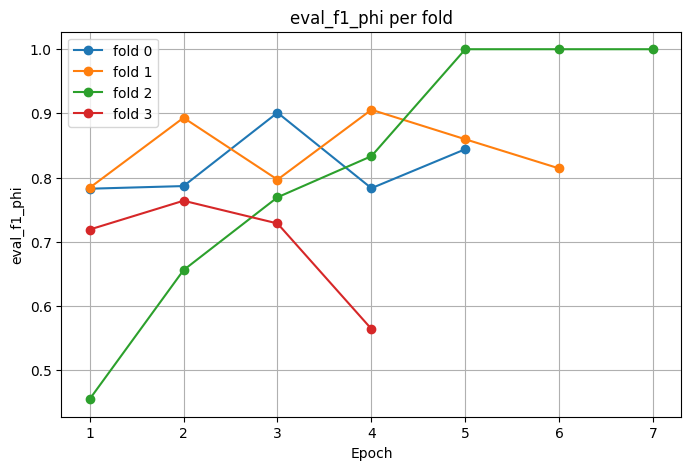

In [ ]:
metric_to_plot = "eval_f1_phi"   # άλλαξέ το αν χρειάζεται

plot_df = full_log_df[full_log_df[metric_to_plot].notna()].copy()

plt.figure(figsize=(8,5))
for fold_id in sorted(plot_df["fold"].unique()):
    tmp = plot_df[plot_df["fold"] == fold_id].copy()
    x = tmp["epoch"] if "epoch" in tmp.columns else range(len(tmp))
    plt.plot(x, tmp[metric_to_plot], marker="o", label=f"fold {fold_id}")

plt.xlabel("Epoch")
plt.ylabel(metric_to_plot)
plt.title(f"{metric_to_plot} per fold")
plt.legend()
plt.grid(True)
plt.show()

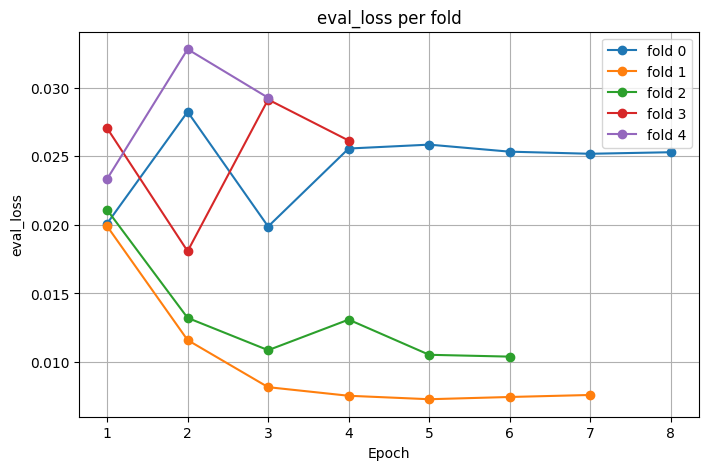

In [ ]:
metric_to_plot = "eval_loss"

plot_df = full_log_df[full_log_df[metric_to_plot].notna()].copy()

plt.figure(figsize=(8,5))
for fold_id in sorted(plot_df["fold"].unique()):
    tmp = plot_df[plot_df["fold"] == fold_id].copy()
    x = tmp["epoch"] if "epoch" in tmp.columns else range(len(tmp))
    plt.plot(x, tmp[metric_to_plot], marker="o", label=f"fold {fold_id}")

plt.xlabel("Epoch")
plt.ylabel(metric_to_plot)
plt.title(f"{metric_to_plot} per fold")
plt.legend()
plt.grid(True)
plt.show()

Πιθανοτητες

In [ ]:
for fold_id, d in all_folds.items():
    print(f"\n=== FOLD {fold_id} ARRAYS ===")
    arrs = d["arrays"]
    if arrs is None:
        print("No arrays found")
        continue

    for k, v in arrs.items():
        try:
            print(k, type(v), np.shape(v), getattr(v, "dtype", None))
        except:
            print(k, type(v))


=== FOLD 0 ARRAYS ===
logits <class 'numpy.ndarray'> (121,) object
labels <class 'numpy.ndarray'> (121,) object
doc_ids <class 'numpy.ndarray'> (121,) int32

=== FOLD 1 ARRAYS ===
logits <class 'numpy.ndarray'> (122, 512, 3) object
labels <class 'numpy.ndarray'> (122, 512) object
doc_ids <class 'numpy.ndarray'> (122,) int32

=== FOLD 2 ARRAYS ===
logits <class 'numpy.ndarray'> (159, 512, 3) object
labels <class 'numpy.ndarray'> (159, 512) object
doc_ids <class 'numpy.ndarray'> (159,) int32

=== FOLD 3 ARRAYS ===
logits <class 'numpy.ndarray'> (157,) object
labels <class 'numpy.ndarray'> (157,) object
doc_ids <class 'numpy.ndarray'> (157,) int32

=== FOLD 4 ARRAYS ===
logits <class 'numpy.ndarray'> (179, 512, 3) object
labels <class 'numpy.ndarray'> (179, 512) object
doc_ids <class 'numpy.ndarray'> (179,) int32


In [ ]:
for fold_id, d in all_folds.items():
    meta = d["meta"]
    print(f"\n=== FOLD {fold_id} META ===")
    if meta is None:
        print("No meta found")
        continue

    print("type:", type(meta))
    if isinstance(meta, dict):
        print("keys:", list(meta.keys()))
        for k, v in meta.items():
            try:
                if hasattr(v, "shape"):
                    print(f"  {k}: shape={v.shape}, type={type(v)}")
                elif isinstance(v, (list, tuple, dict)):
                    print(f"  {k}: type={type(v)}, len={len(v)}")
                else:
                    print(f"  {k}: type={type(v)}")
            except:
                print(f"  {k}: type={type(v)}")


=== FOLD 0 META ===
type: <class 'dict'>
keys: ['experiment', 'offset_mapping', 'texts_per_window', 'test_doc_texts', 'test_doc_entities', 'best_checkpoint', 'best_metric']
  experiment: type=<class 'str'>
  offset_mapping: type=<class 'list'>, len=121
  texts_per_window: type=<class 'NoneType'>
  test_doc_texts: type=<class 'dict'>, len=5
  test_doc_entities: type=<class 'dict'>, len=5
  best_checkpoint: type=<class 'str'>
  best_metric: type=<class 'float'>

=== FOLD 1 META ===
type: <class 'dict'>
keys: ['experiment', 'offset_mapping', 'texts_per_window', 'test_instance_texts', 'test_instance_entities', 'instance_to_original', 'instance_to_source', 'best_checkpoint', 'best_metric']
  experiment: type=<class 'str'>
  offset_mapping: type=<class 'list'>, len=122
  texts_per_window: type=<class 'list'>, len=122
  test_instance_texts: type=<class 'dict'>, len=46
  test_instance_entities: type=<class 'dict'>, len=46
  instance_to_original: type=<class 'dict'>, len=46
  instance_to_sourc

In [ ]:
def softmax_np(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

fold_outputs = {}

for fold_id, d in all_folds.items():
    arrs = d["arrays"]

    # Check the dtype of the loaded logits and labels
    if arrs["logits"].dtype == object:
        # If they are arrays of arrays (dtype=object), process each sub-array
        window_logits_list = arrs["logits"].tolist() # Convert to Python list of arrays
        window_labels_list = arrs["labels"].tolist() # Convert to Python list of arrays
        doc_ids_array = arrs["doc_ids"] # doc_ids should be fine

        processed_probs = [softmax_np(wl, axis=-1) for wl in window_logits_list]
        # Ensure wl is a numpy array before calling argmax
        processed_preds = [np.asarray(wl).argmax(axis=-1) for wl in window_logits_list]

        # Convert back to object arrays to maintain consistency if inner shapes vary
        logits_final = np.array(window_logits_list, dtype=object)
        labels_final = np.array(window_labels_list, dtype=object)
        probs_final = np.array(processed_probs, dtype=object)
        preds_final = np.array(processed_preds, dtype=object)

    else:
        # If they are regular multi-dimensional arrays, process directly
        logits_final = arrs["logits"]
        labels_final = arrs["labels"]
        doc_ids_array = arrs["doc_ids"]

        probs_final = softmax_np(logits_final, axis=-1)
        preds_final = logits_final.argmax(axis=-1)

    fold_outputs[fold_id] = {
        "logits": logits_final,
        "labels": labels_final,
        "doc_ids": doc_ids_array,
        "probs": probs_final,
        "preds": preds_final,
    }

# This part is for printing shapes, and should work fine after the fix
for fold_id, x in fold_outputs.items():
    # To get a descriptive shape for object arrays, we print the outer array's shape.
    # For actual numeric shape, one would inspect individual elements if needed.
    print(
        fold_id,
        x["logits"].shape,
        x["labels"].shape,
        x["doc_ids"].shape,
        x["probs"].shape,
        x["preds"].shape
    )

0 (121,) (121,) (121,) (121,) (121,)
1 (122, 512, 3) (122, 512) (122,) (122, 512, 3) (122, 512)
2 (159, 512, 3) (159, 512) (159,) (159, 512, 3) (159, 512)
3 (157,) (157,) (157,) (157,) (157,)
4 (179, 512, 3) (179, 512) (179,) (179, 512, 3) (179, 512)


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def flatten_valid_tokens(labels, preds):
    # Check if labels is an array of arrays (dtype=object)
    if labels.dtype == object:
        # Concatenate all inner arrays into a single 1D array
        labels_flat = np.concatenate([np.asarray(arr) for arr in labels])
        preds_flat = np.concatenate([np.asarray(arr) for arr in preds])
    else:
        # If it's a regular multi-dimensional array, use it directly
        labels_flat = labels
        preds_flat = preds

    mask = labels_flat != -100
    y_true = labels_flat[mask]
    y_pred = preds_flat[mask]

    # Explicitly cast to integer type to ensure scikit-learn compatibility
    return y_true.astype(int), y_pred.astype(int)

rows = []

for fold_id, x in fold_outputs.items():
    # Ensure labels and preds are handled correctly for object dtype
    y_true, y_pred = flatten_valid_tokens(x["labels"], x["preds"])

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)

    rows.append({
        "fold": fold_id,
        "n_valid_tokens": len(y_true),
        "token_acc": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    })

token_metrics_df = pd.DataFrame(rows).sort_values("fold").reset_index(drop=True)
token_metrics_df

,fold,n_valid_tokens,token_acc,macro_precision,macro_recall,macro_f1
0,0,50988,0.995215,0.796292,0.664928,0.712443
1,1,53377,0.996553,0.916912,0.893711,0.903561
2,2,70732,0.996437,0.978241,0.776590,0.856630
3,3,67061,0.997554,0.946343,0.660981,0.658296
4,4,81341,0.997160,0.646712,0.631488,0.638894


In [ ]:
id2label = {
    0: "O",
    1: "B-PHI",
    2: "I-PHI",
}
label_names = [id2label[i] for i in sorted(id2label)]
label_names

['O', 'B-PHI', 'I-PHI']

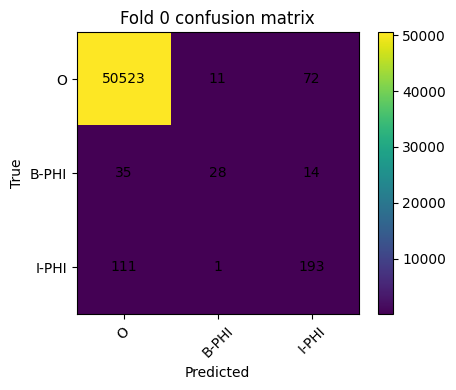

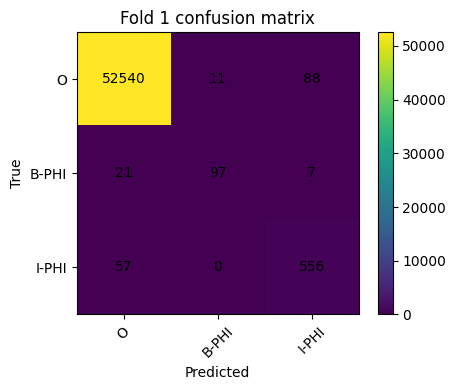

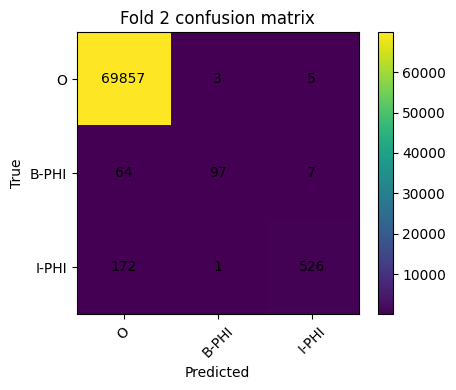

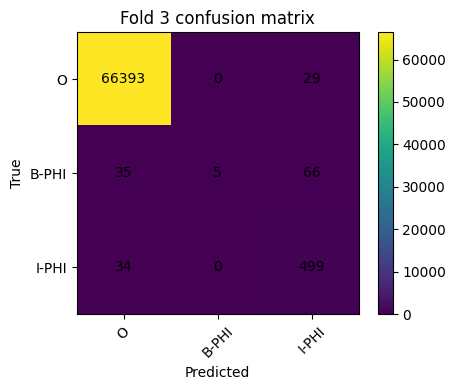

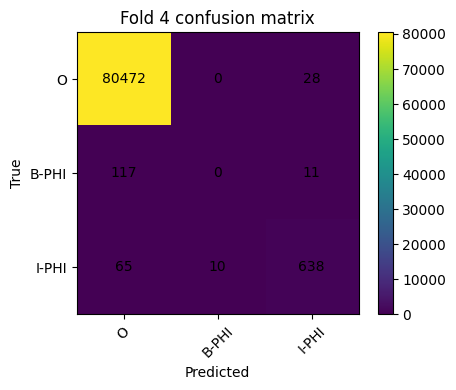

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

for fold_id, x in fold_outputs.items():
    y_true, y_pred = flatten_valid_tokens(x["labels"], x["preds"])
    cm = confusion_matrix(y_true, y_pred, labels=sorted(id2label.keys()))

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)

    ax.set_title(f"Fold {fold_id} confusion matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(len(label_names)))
    ax.set_yticks(range(len(label_names)))
    ax.set_xticklabels(label_names, rotation=45)
    ax.set_yticklabels(label_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

In [ ]:
confidence_rows = []

for fold_id, x in fold_outputs.items():
    labels_raw = x["labels"]
    preds_raw = x["preds"]
    probs_raw = x["probs"]

    # Flatten if they are object arrays (arrays of arrays)
    if labels_raw.dtype == object:
        labels = np.concatenate([np.asarray(arr) for arr in labels_raw])
        preds = np.concatenate([np.asarray(arr) for arr in preds_raw])
        # For probs, each element of probs_raw is (N, 3), so concatenate along axis 0
        probs = np.concatenate([np.asarray(arr) for arr in probs_raw])
    else:
        labels = labels_raw
        preds = preds_raw
        probs = probs_raw

    mask = labels != -100

    pred_conf = probs.max(axis=-1)[mask]
    correct = (preds[mask] == labels[mask])

    confidence_rows.append({
        "fold": fold_id,
        "mean_confidence": pred_conf.mean(),
        "median_confidence": np.median(pred_conf),
        "mean_conf_correct": pred_conf[correct].mean() if correct.any() else np.nan,
        "mean_conf_wrong": pred_conf[~correct].mean() if (~correct).any() else np.nan,
    })

confidence_df = pd.DataFrame(confidence_rows).sort_values("fold").reset_index(drop=True)
confidence_df

,fold,mean_confidence,median_confidence,mean_conf_correct,mean_conf_wrong
0,0,0.998497,0.999911,0.999104,0.872263
1,1,0.997203,0.999869,0.997840,0.813168
2,2,0.998162,0.999830,0.998445,0.918987
3,3,0.996474,0.999447,0.997181,0.707864
4,4,0.987048,0.993987,0.988409,0.508964


In [ ]:
dist_rows = []

for fold_id, x in fold_outputs.items():
    y_true, y_pred = flatten_valid_tokens(x["labels"], x["preds"])

    for lab_id, lab_name in id2label.items():
        dist_rows.append({
            "fold": fold_id,
            "label_id": lab_id,
            "label_name": lab_name,
            "true_count": int((y_true == lab_id).sum()),
            "pred_count": int((y_pred == lab_id).sum()),
        })

label_dist_df = pd.DataFrame(dist_rows).sort_values(["fold", "label_id"]).reset_index(drop=True)
label_dist_df

,fold,label_id,label_name,true_count,pred_count
0,0,0,O,50606,50669
1,0,1,B-PHI,77,40
2,0,2,I-PHI,305,279
3,1,0,O,52639,52618
4,1,1,B-PHI,125,108
5,1,2,I-PHI,613,651
6,2,0,O,69865,70093
7,2,1,B-PHI,168,101
8,2,2,I-PHI,699,538
9,3,0,O,66422,66462


In [ ]:
doc_rows = []

for fold_id, x in fold_outputs.items():
    labels = x["labels"]
    preds = x["preds"]
    doc_ids = x["doc_ids"]
    probs = x["probs"]

    for i, doc_id in enumerate(doc_ids):
        mask = labels[i] != -100
        if mask.sum() == 0:
            continue

        y_true = labels[i][mask]
        y_pred = preds[i][mask]
        conf = probs[i].max(axis=-1)[mask]

        doc_rows.append({
            "fold": fold_id,
            "doc_id": int(doc_id),
            "window_idx": i,
            "n_valid_tokens": int(mask.sum()),
            "token_acc": float((y_true == y_pred).mean()),
            "mean_conf": float(conf.mean()),
            "true_phi_tokens": int((y_true != 0).sum()),
            "pred_phi_tokens": int((y_pred != 0).sum()),
        })

doc_window_df = pd.DataFrame(doc_rows)
doc_window_df.head()

,fold,doc_id,window_idx,n_valid_tokens,token_acc,mean_conf,true_phi_tokens,pred_phi_tokens
0,0,0,0,510,0.994118,0.999497,2,4
1,0,0,1,510,1.000000,0.999901,0,0
2,0,0,2,279,1.000000,0.999895,0,0
3,0,0,3,510,0.988235,0.999039,12,16
4,0,0,4,510,0.996078,0.994011,0,2


In [ ]:
doc_window_df

,fold,doc_id,window_idx,n_valid_tokens,token_acc,mean_conf,true_phi_tokens,pred_phi_tokens
0,0,0,0,510,0.994118,0.999497,2,4
1,0,0,1,510,1.000000,0.999901,0,0
2,0,0,2,279,1.000000,0.999895,0,0
3,0,0,3,510,0.988235,0.999039,12,16
4,0,0,4,510,0.996078,0.994011,0,2
...,...,...,...,...,...,...,...,...
733,4,15,174,510,0.992157,0.991252,4,0
734,4,15,175,510,1.000000,0.992991,0,0
735,4,15,176,510,1.000000,0.993804,0,0
736,4,15,177,510,0.984314,0.976037,8,15


In [ ]:
doc_summary_df = (
    doc_window_df
    .groupby(["fold", "doc_id"], as_index=False)
    .agg({
        "window_idx": "count",
        "n_valid_tokens": "sum",
        "token_acc": "mean",
        "mean_conf": "mean",
        "true_phi_tokens": "sum",
        "pred_phi_tokens": "sum",
    })
    .rename(columns={"window_idx": "n_windows"})
    .sort_values(["fold", "doc_id"])
    .reset_index(drop=True)
)

doc_summary_df.head(20)

,fold,doc_id,n_windows,n_valid_tokens,token_acc,mean_conf,true_phi_tokens,pred_phi_tokens
0,0,0,31,13782,0.995319,0.998915,99,72
1,0,1,28,11743,0.995152,0.998826,96,53
2,0,8,22,9646,0.997453,0.998819,0,28
3,0,13,20,8006,0.992369,0.996542,135,125
4,0,22,20,7811,0.997941,0.999204,52,41
5,1,2,19,6800,0.999381,0.999306,57,55
6,1,16,18,8387,0.997388,0.995010,238,240
7,1,18,31,14680,0.993172,0.994793,381,377
8,1,21,30,12865,0.997333,0.998468,0,39
9,1,23,24,10645,0.998856,0.999519,62,48


In [ ]:
worst_docs = doc_summary_df.sort_values(["token_acc", "n_valid_tokens"], ascending=[True, False])
worst_docs.head(20)

,fold,doc_id,n_windows,n_valid_tokens,token_acc,mean_conf,true_phi_tokens,pred_phi_tokens
3,0,13,20,8006,0.992369,0.996542,135,125
7,1,18,31,14680,0.993172,0.994793,381,377
11,2,10,21,9302,0.993340,0.995391,258,195
15,3,6,30,12237,0.993826,0.991579,254,219
12,2,14,22,9293,0.995137,0.997967,120,76
1,0,1,28,11743,0.995152,0.998826,96,53
0,0,0,31,13782,0.995319,0.998915,99,72
14,2,19,59,27797,0.995375,0.997863,489,364
24,4,15,45,20720,0.995555,0.987081,141,120
22,4,7,49,23233,0.995989,0.981469,589,502


In [ ]:
doc_summary_df["phi_token_diff"] = doc_summary_df["pred_phi_tokens"] - doc_summary_df["true_phi_tokens"]

doc_summary_df.reindex(
    doc_summary_df["phi_token_diff"].abs().sort_values(ascending=False).index
).head(20)

,fold,doc_id,n_windows,n_valid_tokens,token_acc,mean_conf,true_phi_tokens,pred_phi_tokens,phi_token_diff
14,2,19,59,27797,0.995375,0.997863,489,364,-125
22,4,7,49,23233,0.995989,0.981469,589,502,-87
11,2,10,21,9302,0.993340,0.995391,258,195,-63
20,4,3,30,13211,0.996144,0.987351,111,60,-51
12,2,14,22,9293,0.995137,0.997967,120,76,-44
1,0,1,28,11743,0.995152,0.998826,96,53,-43
8,1,21,30,12865,0.997333,0.998468,0,39,39
15,3,6,30,12237,0.993826,0.991579,254,219,-35
2,0,8,22,9646,0.997453,0.998819,0,28,28
0,0,0,31,13782,0.995319,0.998915,99,72,-27


In [ ]:
token_rows = []

for fold_id, x in fold_outputs.items():
    labels = x["labels"]
    preds = x["preds"]
    probs = x["probs"]
    doc_ids = x["doc_ids"]

    # Get the number of windows (outer dimension)
    n_windows = len(labels)

    for i in range(n_windows):
        # Get the sequence length for the current window (inner dimension)
        # This handles both 2D arrays and 1D object arrays where labels[i] is an array
        seq_len = len(labels[i])

        for j in range(seq_len):
            if labels[i][j] == -100:
                continue

            token_rows.append({
                "fold": fold_id,
                "window_idx": i,
                "doc_id": int(doc_ids[i]),
                "token_pos": j,
                "true_label": int(labels[i][j]),
                "pred_label": int(preds[i][j]),
                "correct": int(labels[i][j] == preds[i][j]),
                "pred_conf": float(probs[i][j].max()),
            })

all_tokens_df = pd.DataFrame(token_rows)
all_tokens_df.head()

,fold,window_idx,doc_id,token_pos,true_label,pred_label,correct,pred_conf
0,0,0,0,1,0,0,1,0.999910
1,0,0,0,2,0,0,1,0.999920
2,0,0,0,3,0,0,1,0.999924
3,0,0,0,4,0,0,1,0.999927
4,0,0,0,5,0,0,1,0.999912


In [ ]:
all_tokens_df.groupby(["fold", "true_label"])["correct"].mean()

fold  true_label
0     0             0.998360
      1             0.363636
      2             0.632787
1     0             0.998119
      1             0.776000
      2             0.907015
2     0             0.999885
      1             0.577381
      2             0.752504
3     0             0.999563
      1             0.047170
      2             0.936210
4     0             0.999652
      1             0.000000
      2             0.894811
Name: correct, dtype: float64

In [ ]:
phi_rows = []

for fold_id, x in fold_outputs.items():
    y_true, y_pred = flatten_valid_tokens(x["labels"], x["preds"])

    phi_mask = y_true != 0
    if phi_mask.sum() == 0:
        continue

    phi_acc = (y_true[phi_mask] == y_pred[phi_mask]).mean()

    phi_rows.append({
        "fold": fold_id,
        "n_phi_tokens": int(phi_mask.sum()),
        "phi_token_acc": float(phi_acc),
    })

phi_acc_df = pd.DataFrame(phi_rows).sort_values("fold").reset_index(drop=True)
phi_acc_df

,fold,n_phi_tokens,phi_token_acc
0,0,382,0.578534
1,1,738,0.884824
2,2,867,0.718570
3,3,639,0.788732
4,4,841,0.758621


In [ ]:
binary_rows = []

for fold_id, x in fold_outputs.items():
    y_true, y_pred = flatten_valid_tokens(x["labels"], x["preds"])

    y_true_bin = (y_true != 0).astype(int)
    y_pred_bin = (y_pred != 0).astype(int)

    p, r, f1, _ = precision_recall_fscore_support(
        y_true_bin, y_pred_bin, average="binary", zero_division=0
    )

    binary_rows.append({
        "fold": fold_id,
        "phi_vs_o_precision": p,
        "phi_vs_o_recall": r,
        "phi_vs_o_f1": f1,
    })

binary_df = pd.DataFrame(binary_rows).sort_values("fold").reset_index(drop=True)
binary_df

,fold,phi_vs_o_precision,phi_vs_o_recall,phi_vs_o_f1
0,0,0.739812,0.617801,0.673324
1,1,0.869565,0.894309,0.881764
2,2,0.987480,0.727797,0.837981
3,3,0.951586,0.892019,0.920840
4,4,0.959243,0.783591,0.862565


meta

In [ ]:
def normalize_offset_pair(pair):
    if pair is None:
        return None
    if isinstance(pair, np.ndarray):
        pair = pair.tolist()
    if isinstance(pair, tuple):
        pair = list(pair)
    if not isinstance(pair, (list, tuple)) or len(pair) != 2:
        return None
    return int(pair[0]), int(pair[1])

def is_valid_token(offset, label_id):
    if label_id == -100:
        return False
    offset = normalize_offset_pair(offset)
    if offset is None:
        return False
    start, end = offset
    if start == end:
        return False
    return True

def labels_to_spans(label_ids, offsets, text, id2label):
    """
    Converts one token-label sequence into character spans.
    Returns list of dicts:
      {
        'start': int,
        'end': int,
        'label': 'PHI',
        'text': substring
      }
    """
    spans = []
    current_start = None
    current_end = None
    current_type = None

    for lab_id, off in zip(label_ids, offsets):
        off = normalize_offset_pair(off)

        if not is_valid_token(off, lab_id):
            if current_start is not None:
                spans.append({
                    "start": current_start,
                    "end": current_end,
                    "label": current_type,
                    "text": text[current_start:current_end],
                })
                current_start, current_end, current_type = None, None, None
            continue

        start, end = off
        tag = id2label[int(lab_id)]

        if tag == "O":
            if current_start is not None:
                spans.append({
                    "start": current_start,
                    "end": current_end,
                    "label": current_type,
                    "text": text[current_start:current_end],
                })
                current_start, current_end, current_type = None, None, None
            continue

        if "-" in tag:
            prefix, ent_type = tag.split("-", 1)
        else:
            prefix, ent_type = "I", tag

        if prefix == "B":
            if current_start is not None:
                spans.append({
                    "start": current_start,
                    "end": current_end,
                    "label": current_type,
                    "text": text[current_start:current_end],
                })
            current_start = start
            current_end = end
            current_type = ent_type

        elif prefix == "I":
            if current_start is None:
                current_start = start
                current_end = end
                current_type = ent_type
            elif current_type != ent_type:
                spans.append({
                    "start": current_start,
                    "end": current_end,
                    "label": current_type,
                    "text": text[current_start:current_end],
                })
                current_start = start
                current_end = end
                current_type = ent_type
            else:
                current_end = max(current_end, end)

    if current_start is not None:
        spans.append({
            "start": current_start,
            "end": current_end,
            "label": current_type,
            "text": text[current_start:current_end],
        })

    return spans

In [ ]:
def merge_spans(spans):
    """
    Merge exact / overlapping spans of same label.
    """
    if not spans:
        return []

    spans = sorted(spans, key=lambda x: (x["start"], x["end"], x["label"]))
    merged = [spans[0].copy()]

    for sp in spans[1:]:
        last = merged[-1]

        same_label = sp["label"] == last["label"]
        overlaps = sp["start"] <= last["end"]

        if same_label and overlaps:
            last["end"] = max(last["end"], sp["end"])
            last["text"] = last.get("text", "")
        elif same_label and sp["start"] == last["start"] and sp["end"] == last["end"]:
            pass
        else:
            merged.append(sp.copy())

    return merged

def deduplicate_exact_spans(spans):
    seen = set()
    out = []
    for sp in spans:
        key = (sp["start"], sp["end"], sp["label"])
        if key not in seen:
            seen.add(key)
            out.append(sp)
    return out

In [ ]:
def build_doc_level_predictions_for_fold(fold_data, id2label):
    preds = fold_data["preds"]
    labels = fold_data["labels"]
    doc_ids = fold_data["doc_ids"]

    # Safely get offset_mapping and texts_per_window, and ensure they are lists
    offsets_per_window_raw = fold_data.get("offset_mapping")
    offsets_per_window = offsets_per_window_raw if offsets_per_window_raw is not None else []

    texts_per_window_raw = fold_data.get("texts_per_window")
    texts_per_window = texts_per_window_raw if texts_per_window_raw is not None else []

    # Safely get test_doc_texts, defaulting to an empty dict if None or missing
    test_doc_texts = fold_data.get("test_doc_texts", {})

    pred_spans_by_doc = {}
    gold_token_spans_by_doc = {}

    num_windows = len(doc_ids)
    # Check if there are no windows or if essential metadata lists are empty
    if num_windows == 0 or not offsets_per_window or not texts_per_window:
        return {}, {}

    for i in range(num_windows):
        doc_id = int(doc_ids[i])

        # Access text and offsets safely, now that they are guaranteed to be lists
        # Use a bounds check to prevent IndexError if num_windows is inconsistent with list lengths
        text = texts_per_window[i] if i < len(texts_per_window) else ""
        offsets = offsets_per_window[i] if i < len(offsets_per_window) else []

        pred_label_ids = preds[i]
        gold_label_ids = labels[i]

        pred_spans = labels_to_spans(pred_label_ids, offsets, text, id2label)
        gold_spans = labels_to_spans(gold_label_ids, offsets, text, id2label)

        pred_spans_by_doc.setdefault(doc_id, []).extend(pred_spans)
        gold_token_spans_by_doc.setdefault(doc_id, []).extend(gold_spans)

    final_pred_spans_by_doc = {}
    final_gold_token_spans_by_doc = {}

    for doc_id, spans in pred_spans_by_doc.items():
        spans = deduplicate_exact_spans(spans)
        spans = merge_spans(spans)
        # Safely get full_text, defaulting to an empty string if not found or None
        full_text = test_doc_texts.get(doc_id, "")
        for sp in spans:
            sp["text"] = full_text[sp["start"]:sp["end"]] if isinstance(full_text, str) else ""
        final_pred_spans_by_doc[doc_id] = spans

    for doc_id, spans in gold_token_spans_by_doc.items():
        spans = deduplicate_exact_spans(spans)
        spans = merge_spans(spans)
        # Safely get full_text, defaulting to an empty string if not found or None
        full_text = test_doc_texts.get(doc_id, "")
        for sp in spans:
            sp["text"] = full_text[sp["start"]:sp["end"]] if isinstance(full_text, str) else ""
        final_gold_token_spans_by_doc[doc_id] = spans

    return final_pred_spans_by_doc, final_gold_token_spans_by_doc

In [ ]:
doc_predictions = {}

for fold_id, fold_output_data in fold_outputs.items():
    # Retrieve the original fold data which contains 'meta'
    original_fold_data = all_folds[fold_id]

    # Combine processed data with metadata required by the function
    combined_data = {
        **fold_output_data,  # Contains logits, labels, preds, probs, doc_ids
        **original_fold_data['meta'], # Contains offset_mapping, texts_per_window, test_doc_texts
    }

    pred_spans_by_doc, gold_token_spans_by_doc = build_doc_level_predictions_for_fold(
        combined_data, id2label
    )
    doc_predictions[fold_id] = {
        "pred_spans_by_doc": pred_spans_by_doc,
        "gold_token_spans_by_doc": gold_token_spans_by_doc,
    }

for fold_id, x in doc_predictions.items():
    print(f"\nFOLD {fold_id}")
    for doc_id in sorted(x["pred_spans_by_doc"].keys()):
        print(
            "doc", doc_id,
            "pred_spans", len(x["pred_spans_by_doc"].get(doc_id, [])),
            "gold_token_spans", len(x["gold_token_spans_by_doc"].get(doc_id, []))
        )


FOLD 0

FOLD 1

FOLD 2

FOLD 3

FOLD 4


In [ ]:
import pickle
import os

SAVE_DIR = "/content/drive/MyDrive/Archimedes_Anonymization/xlmr_phi_cv_results/"
fp = os.path.join(SAVE_DIR, "orig_syn_syn", "fold_0_meta.pkl")

with open(fp, "rb") as f:
    meta = pickle.load(f)

print(meta.keys())

dict_keys(['experiment', 'offset_mapping', 'texts_per_window', 'test_doc_texts', 'test_doc_entities', 'best_checkpoint', 'best_metric'])


In [ ]:
print(type(meta.get("offset_mapping")))
print(type(meta.get("texts_per_window")))
print(type(meta.get("test_doc_texts")))

print("n offsets:", len(meta.get("offset_mapping", [])) if meta.get("offset_mapping") is not None else None)
print("n texts_per_window:", len(meta.get("texts_per_window", [])) if meta.get("texts_per_window") is not None else None)
print("n test_doc_texts:", len(meta.get("test_doc_texts", {})) if meta.get("test_doc_texts") is not None else None)

<class 'list'>
<class 'NoneType'>
<class 'dict'>
n offsets: 121
n texts_per_window: None
n test_doc_texts: 5


In [ ]:
import numpy as np

fp = os.path.join(SAVE_DIR, "orig_syn_syn", "fold_0_arrays.npz")
arr = np.load(fp, allow_pickle=True)

print(arr.files)
print("n logits:", len(arr["logits"]))
print("n labels:", len(arr["labels"]))
print("n doc_ids:", len(arr["doc_ids"]))

['logits', 'labels', 'doc_ids']
n logits: 121
n labels: 121
n doc_ids: 121


In [ ]:
for fold_id, fold_data_processed in fold_outputs.items():
    print(f"\n=== FOLD {fold_id} GOLD ENTITY EXAMPLES ===")
    # Access test_doc_entities from the original all_folds meta data
    test_doc_entities = all_folds[fold_id]["meta"]["test_doc_entities"]
    for doc_id, ents in list(test_doc_entities.items())[:2]:
        print("doc_id:", doc_id)
        print("type:", type(ents))
        print("value:", ents[:3] if isinstance(ents, list) else ents)


=== FOLD 0 GOLD ENTITY EXAMPLES ===
doc_id: 0
type: <class 'list'>
value: [{'start': 114, 'end': 123, 'label': 'HOSPITAL'}, {'start': 457, 'end': 463, 'label': 'HOSPITAL'}]
doc_id: 1
type: <class 'list'>
value: [{'start': 73, 'end': 88, 'label': 'HOSPITAL'}]

=== FOLD 1 GOLD ENTITY EXAMPLES ===
doc_id: 2
type: <class 'list'>
value: [{'start': 405, 'end': 421, 'label': 'HOSPITAL'}]
doc_id: 21
type: <class 'list'>
value: []

=== FOLD 2 GOLD ENTITY EXAMPLES ===
doc_id: 5
type: <class 'list'>
value: []
doc_id: 17
type: <class 'list'>
value: []

=== FOLD 3 GOLD ENTITY EXAMPLES ===
doc_id: 6
type: <class 'list'>
value: [{'start': 1750, 'end': 1768, 'label': 'PERSON'}]
doc_id: 9
type: <class 'list'>
value: []

=== FOLD 4 GOLD ENTITY EXAMPLES ===
doc_id: 3
type: <class 'list'>
value: [{'start': 1827, 'end': 1836, 'label': 'HOSPITAL'}]
doc_id: 4
type: <class 'list'>
value: []


In [ ]:
def normalize_gold_entities(raw_entities, full_text):
    """
    Try to normalize saved gold entities into:
    {'start': int, 'end': int, 'label': str, 'text': str}
    """
    normalized = []

    if raw_entities is None:
        return normalized

    for ent in raw_entities:
        start = end = label = None

        if isinstance(ent, dict):
            start = ent.get("start", ent.get("begin"))
            end = ent.get("end", ent.get("stop"))
            label = ent.get("label", ent.get("entity", ent.get("type", "PHI")))

        elif isinstance(ent, (list, tuple)):
            if len(ent) >= 3:
                start, end, label = ent[0], ent[1], ent[2]
            elif len(ent) == 2:
                start, end = ent
                label = "PHI"

        if start is None or end is None:
            continue

        start = int(start)
        end = int(end)
        label = str(label)

        normalized.append({
            "start": start,
            "end": end,
            "label": label,
            "text": full_text[start:end],
        })

    normalized = sorted(normalized, key=lambda x: (x["start"], x["end"], x["label"]))
    return normalized

In [ ]:
gold_entities_by_fold = {}

for fold_id, fold_output_data in fold_outputs.items():
    # Access meta data from all_folds for text and entities
    meta_data = all_folds[fold_id]['meta']
    full_texts = meta_data["test_doc_texts"]
    raw_gold = meta_data["test_doc_entities"]

    norm = {}
    for doc_id, ents in raw_gold.items():
        norm[int(doc_id)] = normalize_gold_entities(ents, full_texts[int(doc_id)])

    gold_entities_by_fold[fold_id] = norm

for fold_id, docs in gold_entities_by_fold.items():
    print(f"\nFOLD {fold_id}")
    for doc_id, ents in list(docs.items())[:2]:
        print("doc", doc_id, "n_gold_entities", len(ents))
        print(ents[:2])


FOLD 0
doc 0 n_gold_entities 2
[{'start': 114, 'end': 123, 'label': 'HOSPITAL', 'text': 'ΓΝ Δράμας'}, {'start': 457, 'end': 463, 'label': 'HOSPITAL', 'text': 'Δράμας'}]
doc 1 n_gold_entities 1
[{'start': 73, 'end': 88, 'label': 'HOSPITAL', 'text': 'ΓΝΑ Ιπποκράτειο'}]

FOLD 1
doc 2 n_gold_entities 1
[{'start': 405, 'end': 421, 'label': 'HOSPITAL', 'text': 'ΓΝΑ Ευαγγελισμός'}]
doc 21 n_gold_entities 0
[]

FOLD 2
doc 5 n_gold_entities 0
[]
doc 17 n_gold_entities 0
[]

FOLD 3
doc 6 n_gold_entities 1
[{'start': 1750, 'end': 1768, 'label': 'PERSON', 'text': 'Γαλάτεια Περουλάκη'}]
doc 9 n_gold_entities 0
[]

FOLD 4
doc 3 n_gold_entities 1
[{'start': 1827, 'end': 1836, 'label': 'HOSPITAL', 'text': 'ΓΝΑ Λαϊκό'}]
doc 4 n_gold_entities 0
[]


In [ ]:
def span_key(sp):
    return (int(sp["start"]), int(sp["end"]), str(sp["label"]))

def compare_spans_exact(pred_spans, gold_spans):
    pred_set = {span_key(x) for x in pred_spans}
    gold_set = {span_key(x) for x in gold_spans}

    tp = pred_set & gold_set
    fp = pred_set - gold_set
    fn = gold_set - pred_set

    return tp, fp, fn

In [ ]:
def spans_overlap(a, b):
    return a["start"] < b["end"] and a["end"] > b["start"]

In [ ]:
def compare_spans_overlap(pred_spans, gold_spans):

    matched_gold = set()
    matched_pred = set()

    for i, p in enumerate(pred_spans):
        for j, g in enumerate(gold_spans):
            if spans_overlap(p, g):
                matched_pred.add(i)
                matched_gold.add(j)
                break

    tp = len(matched_pred)
    fp = len(pred_spans) - tp
    fn = len(gold_spans) - len(matched_gold)

    return tp, fp, fn

In [ ]:
doc_eval_rows = []

for fold_id, fold_data in fold_outputs.items():
    pred_spans_by_doc = doc_predictions[fold_id]["pred_spans_by_doc"]
    gold_spans_by_doc = gold_entities_by_fold[fold_id]

    all_doc_ids = sorted(set(pred_spans_by_doc.keys()) | set(gold_spans_by_doc.keys()))

    for doc_id in all_doc_ids:
        pred_spans = pred_spans_by_doc.get(doc_id, [])
        gold_spans = gold_spans_by_doc.get(doc_id, [])

        tp, fp, fn = compare_spans_overlap(pred_spans, gold_spans)

        n_pred = len(pred_spans)
        n_gold = len(gold_spans)

        # Handle the case where both n_pred and n_gold are 0 as a perfect score
        if n_pred == 0 and n_gold == 0:
            p = 1.0
            r = 1.0
            f1 = 1.0
        else:
            p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

        doc_eval_rows.append({
            "fold": fold_id,
            "doc_id": doc_id,
            "n_pred": n_pred,
            "n_gold": n_gold,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": p,
            "recall": r,
            "f1": f1,
        })

doc_entity_eval_df = (
    pd.DataFrame(doc_eval_rows)
    .sort_values(["fold", "doc_id"])
    .reset_index(drop=True)
)

doc_entity_eval_df

,fold,doc_id,n_pred,n_gold,tp,fp,fn,precision,recall,f1
0,0,0,16,2,2,14,0,0.125000,1.0,0.222222
1,0,1,6,1,0,6,1,0.000000,0.0,0.000000
2,0,8,3,0,0,3,0,0.000000,0.0,0.000000
3,0,13,11,2,1,10,1,0.090909,0.5,0.153846
4,0,22,5,1,0,5,1,0.000000,0.0,0.000000
5,1,2,7,1,1,6,0,0.142857,1.0,0.250000
6,1,16,27,3,3,24,0,0.111111,1.0,0.200000
7,1,18,44,5,4,40,1,0.090909,0.8,0.163265
8,1,21,8,0,0,8,0,0.000000,0.0,0.000000
9,1,23,3,1,1,2,0,0.333333,1.0,0.500000


In [ ]:
overall_entity_metrics = pd.DataFrame([
    {
        "metric": "precision",
        "mean": doc_entity_eval_df["precision"].mean(),
        "std": doc_entity_eval_df["precision"].std(),
    },
    {
        "metric": "recall",
        "mean": doc_entity_eval_df["recall"].mean(),
        "std": doc_entity_eval_df["recall"].std(),
    },
    {
        "metric": "f1",
        "mean": doc_entity_eval_df["f1"].mean(),
        "std": doc_entity_eval_df["f1"].std(),
    },
])

print("Overall Entity-Level Metrics (Overlap-based):")
print(overall_entity_metrics)

Overall Entity-Level Metrics (Overlap-based):
      metric      mean       std
0  precision  0.192729  0.317200
1     recall  0.612000  0.434281
2         f1  0.241713  0.316571


In [ ]:
per_fold_entity_metrics = (
    doc_entity_eval_df.groupby("fold")
    [["precision", "recall", "f1"]]
    .mean()
    .reset_index()
)

print("Entity-Level Metrics Per Fold (Overlap-based):")
print(per_fold_entity_metrics)

Entity-Level Metrics Per Fold (Overlap-based):
   fold  precision  recall        f1
0     0   1.000000    0.88  0.914286
1     1   0.960000    0.96  0.960000
2     2   0.886667    1.00  0.931818
3     3   1.000000    1.00  1.000000
4     4   1.000000    1.00  1.000000


In [ ]:
# @title
import html
import numpy as np
import pandas as pd

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets


# =========================================================
# COLORS (dark-mode friendly)
# =========================================================

COLOR_TP = "#34d399"   # green
COLOR_FP = "#c084fc"   # purple
COLOR_FN = "#60a5fa"   # blue
COLOR_MIXED = "#f59e0b"  # amber


# =========================================================
# BASIC HELPERS
# =========================================================

def esc(x):
    return html.escape(str(x))


def context_snippet(text, start, end, window=60):
    left = max(0, start - window)
    right = min(len(text), end + window)
    return text[left:right].replace("\n", " ")


def spans_overlap(a, b):
    return a["start"] < b["end"] and a["end"] > b["start"]


def classify_spans(pred_spans, gold_spans):
    """
    Overlap-based span matching:
    pred overlapping any gold => TP
    unmatched pred => FP
    unmatched gold => FN
    """
    tp = []
    fp = []
    fn = []

    matched_gold = set()

    for p in pred_spans:
        found = False
        for i, g in enumerate(gold_spans):
            if spans_overlap(p, g):
                tp.append(p)
                matched_gold.add(i)
                found = True
                break
        if not found:
            fp.append(p)

    for i, g in enumerate(gold_spans):
        if i not in matched_gold:
            fn.append(g)

    return tp, fp, fn


# =========================================================
# TOKEN EXTRACTION
# =========================================================

def extract_doc_token_rows(fold_outputs, doc_id, fold_id, id2label):
    """
    Builds a token-level dataframe for one document from all overlapping windows.
    Assumes label id 0 = O, and !=0 means PHI.
    """

    fold_data = fold_outputs[fold_id]

    doc_ids = fold_data["doc_ids"]
    labels = fold_data["labels"]
    preds = fold_data["preds"]
    probs = fold_data["probs"]
    offsets_per_window = fold_data["offset_mapping"]
    texts_per_window = fold_data["texts_per_window"]

    label_ids_sorted = sorted(id2label.keys())
    rows = []

    for w_idx in range(len(doc_ids)):
        if int(doc_ids[w_idx]) != int(doc_id):
            continue

        text = texts_per_window[w_idx]
        offsets = offsets_per_window[w_idx]

        for tok_idx in range(len(offsets)):
            off = offsets[tok_idx]

            if isinstance(off, np.ndarray):
                off = off.tolist()
            if isinstance(off, tuple):
                off = list(off)

            if not isinstance(off, (list, tuple)) or len(off) != 2:
                continue

            start, end = int(off[0]), int(off[1])
            gold_id = int(labels[w_idx][tok_idx])

            if gold_id == -100:
                continue
            if start == end:
                continue

            pred_id = int(preds[w_idx][tok_idx])
            token_text = text[start:end]
            pred_conf = float(probs[w_idx][tok_idx][pred_id])

            gold_is_phi = gold_id != 0
            pred_is_phi = pred_id != 0

            if pred_is_phi and gold_is_phi:
                token_status = "TP"
            elif pred_is_phi and not gold_is_phi:
                token_status = "FP"
            elif (not pred_is_phi) and gold_is_phi:
                token_status = "FN"
            else:
                token_status = "TN"

            row = {
                "window_idx": w_idx,
                "token_idx": tok_idx,
                "start": start,
                "end": end,
                "token": token_text,
                "gold_id": gold_id,
                "gold": id2label[gold_id],
                "pred_id": pred_id,
                "pred": id2label[pred_id],
                "token_status": token_status,
                "correct_exact": gold_id == pred_id,
                "pred_conf": pred_conf,
            }

            for lab_id in label_ids_sorted:
                row[f"p_{id2label[lab_id]}"] = float(probs[w_idx][tok_idx][lab_id])

            rows.append(row)

    df = pd.DataFrame(rows)

    if len(df) == 0:
        return df

    df = df.sort_values(
        ["start", "end", "window_idx", "token_idx"]
    ).reset_index(drop=True)

    return df


# =========================================================
# DEDUPLICATED TOKEN VIEW
# =========================================================

def deduplicate_doc_token_rows(token_df):
    """
    Because overlapping windows may repeat the same token span,
    keep one row per (start, end, token), choosing the row with max pred_conf.
    """
    if token_df.empty:
        return token_df.copy()

    tmp = token_df.copy()
    tmp = tmp.sort_values(
        ["start", "end", "token", "pred_conf"],
        ascending=[True, True, True, False]
    )

    dedup = (
        tmp.groupby(["start", "end", "token"], as_index=False)
        .first()
        .sort_values(["start", "end"])
        .reset_index(drop=True)
    )

    return dedup


# =========================================================
# SPAN CONFIDENCE
# =========================================================

def span_confidence(span, token_df):
    """
    Mean predicted confidence for tokens fully inside this span.
    """
    if token_df.empty:
        return None

    tok = token_df[
        (token_df["start"] >= span["start"]) &
        (token_df["end"] <= span["end"])
    ]

    if len(tok) == 0:
        return None

    return float(tok["pred_conf"].mean())


# =========================================================
# TOKEN TABLE STYLING
# =========================================================

def confidence_to_alpha(conf, min_alpha=0.10, max_alpha=0.95):
    conf = max(0.0, min(1.0, float(conf)))
    return min_alpha + (max_alpha - min_alpha) * conf


def rgba_from_hex(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r}, {g}, {b}, {alpha:.3f})"


def style_token_table(df):
    if df.empty:
        return df

    prob_cols = [c for c in df.columns if c.startswith("p_")]

    def row_style(row):
        status = row["token_status"]
        conf = row.get("pred_conf", 0.0)
        alpha = confidence_to_alpha(conf)

        if status == "TP":
            bg = rgba_from_hex(COLOR_TP, alpha)
            return [f"background-color: {bg}; color: black"] * len(row)
        elif status == "FP":
            bg = rgba_from_hex(COLOR_FP, alpha)
            return [f"background-color: {bg}; color: black"] * len(row)
        elif status == "FN":
            bg = rgba_from_hex(COLOR_FN, alpha)
            return [f"background-color: {bg}; color: black"] * len(row)
        else:
            return [""] * len(row)

    fmt = {"pred_conf": "{:.4f}"}
    for c in prob_cols:
        fmt[c] = "{:.4f}"

    return df.style.apply(row_style, axis=1).format(fmt)


# =========================================================
# RENDER TEXT WITH SPANS + TOOLTIPS
# =========================================================

def render_text_with_spans(text, pred_spans, gold_spans, token_df):
    tp, fp, fn = classify_spans(pred_spans, gold_spans)

    styled_spans = []

    for s in tp:
        styled_spans.append({
            "start": s["start"],
            "end": s["end"],
            "kind": "tp",
            "label": s.get("label", "PHI"),
            "conf": span_confidence(s, token_df),
            "text": s.get("text", text[s["start"]:s["end"]]),
        })

    for s in fp:
        styled_spans.append({
            "start": s["start"],
            "end": s["end"],
            "kind": "fp",
            "label": s.get("label", "PHI"),
            "conf": span_confidence(s, token_df),
            "text": s.get("text", text[s["start"]:s["end"]]),
        })

    for s in fn:
        styled_spans.append({
            "start": s["start"],
            "end": s["end"],
            "kind": "fn",
            "label": s.get("label", "PHI"),
            "conf": span_confidence(s, token_df),
            "text": s.get("text", text[s["start"]:s["end"]]),
        })

    events = []
    for i, s in enumerate(styled_spans):
        events.append((s["start"], 0, i, "start"))
        events.append((s["end"], 1, i, "end"))
    events.sort()

    def style_for_active(active_spans):
        if not active_spans:
            return None

        kinds = {x["kind"] for x in active_spans}

        if kinds == {"tp"}:
            return COLOR_TP
        if kinds == {"fp"}:
            return COLOR_FP
        if kinds == {"fn"}:
            return COLOR_FN

        return COLOR_MIXED

    html_parts = []
    pos = 0
    active = []

    def tooltip_for_active(active_spans):
        if not active_spans:
            return ""

        lines = []
        for s in active_spans:
            conf_txt = "n/a" if s["conf"] is None else f"{s['conf']:.3f}"
            lines.append(
                f"{s['kind'].upper()} | {s['label']} | {s['start']}:{s['end']} | conf={conf_txt} | {s['text']}"
            )
        return "&#10;".join(esc(x) for x in lines)

    for event_pos, _, idx, ev_type in events:
        if pos < event_pos:
            chunk = esc(text[pos:event_pos])
            style = style_for_active(active)

            if style is None:
                html_parts.append(chunk)
            else:
                tooltip = tooltip_for_active(active)
                html_parts.append(
                    f'<span title="{tooltip}" '
                    f'style="background:{style}; color:black; padding:1px 2px; border-radius:3px;">{chunk}</span>'
                )

        span_info = styled_spans[idx]

        if ev_type == "start":
            active.append(span_info)
        else:
            active = [x for x in active if x is not span_info]

        pos = event_pos

    if pos < len(text):
        chunk = esc(text[pos:])
        style = style_for_active(active)

        if style is None:
            html_parts.append(chunk)
        else:
            tooltip = tooltip_for_active(active)
            html_parts.append(
                f'<span title="{tooltip}" '
                f'style="background:{style}; color:black; padding:1px 2px; border-radius:3px;">{chunk}</span>'
            )

    legend = f"""
    <div style="margin-bottom:10px; font-size:14px;">
      <span style="background:{COLOR_TP}; color:black; padding:3px 8px; border-radius:4px;">TP</span>
      <span style="background:{COLOR_FP}; color:black; padding:3px 8px; border-radius:4px; margin-left:8px;">FP</span>
      <span style="background:{COLOR_FN}; color:black; padding:3px 8px; border-radius:4px; margin-left:8px;">FN</span>
      <span style="background:{COLOR_MIXED}; color:black; padding:3px 8px; border-radius:4px; margin-left:8px;">Mixed</span>
    </div>
    """

    block = f"""
    {legend}
    <div style="
        white-space: pre-wrap;
        font-family: monospace;
        font-size: 14px;
        line-height: 1.65;
        border: 1px solid #ddd;
        border-radius: 8px;
        padding: 14px;
        max-height: 500px;
        overflow-y: auto;
    ">
        {''.join(html_parts)}
    </div>
    """

    return block, tp, fp, fn


# =========================================================
# SPAN TABLES
# =========================================================

def spans_to_df(spans, full_text, status):
    rows = []
    for s in spans:
        rows.append({
            "status": status,
            "start": s["start"],
            "end": s["end"],
            "label": s.get("label", "PHI"),
            "text": s.get("text", full_text[s["start"]:s["end"]]),
            "snippet": context_snippet(full_text, s["start"], s["end"], window=50),
        })
    return pd.DataFrame(rows)


# =========================================================
# DOC SUMMARY
# =========================================================

def build_doc_summary_html(fold_id, doc_id, pred_spans, gold_spans, tp, fp, fn, full_text):
    p = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0.0
    r = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

    html_block = f"""
    <div style="display:grid; grid-template-columns: repeat(4, minmax(120px, 1fr)); gap:10px; margin: 8px 0 14px 0;">
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">Fold</div>
        <div style="font-size:18px; font-weight:600;">{fold_id}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">Doc ID</div>
        <div style="font-size:18px; font-weight:600;">{doc_id}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">Text length</div>
        <div style="font-size:18px; font-weight:600;">{len(full_text)}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">Pred / Gold</div>
        <div style="font-size:18px; font-weight:600;">{len(pred_spans)} / {len(gold_spans)}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">TP</div>
        <div style="font-size:18px; font-weight:600; color:{COLOR_TP};">{len(tp)}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">FP</div>
        <div style="font-size:18px; font-weight:600; color:{COLOR_FP};">{len(fp)}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">FN</div>
        <div style="font-size:18px; font-weight:600; color:{COLOR_FN};">{len(fn)}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">F1</div>
        <div style="font-size:18px; font-weight:600;">{f1:.4f}</div>
      </div>
    </div>
    """
    return html_block


# =========================================================
# MAIN DOC RENDER
# =========================================================

def render_doc_view(
    fold_outputs,
    doc_predictions,
    gold_entities_by_fold,
    id2label,
    fold_id,
    doc_id,
    show_tokens=True,
    only_error_tokens=False,
    show_all_probabilities=True,
    deduplicate_tokens=True,
    show_span_tables=True,
):
    full_text = fold_outputs[fold_id]["test_doc_texts"][doc_id]

    pred_spans = doc_predictions[fold_id]["pred_spans_by_doc"].get(doc_id, [])
    gold_spans = gold_entities_by_fold[fold_id].get(doc_id, [])

    token_df = extract_doc_token_rows(
        fold_outputs=fold_outputs,
        doc_id=doc_id,
        fold_id=fold_id,
        id2label=id2label
    )

    token_df_for_display = deduplicate_doc_token_rows(token_df) if deduplicate_tokens else token_df.copy()

    text_html, tp, fp, fn = render_text_with_spans(
        full_text,
        pred_spans,
        gold_spans,
        token_df_for_display
    )

    summary_html = build_doc_summary_html(
        fold_id, doc_id, pred_spans, gold_spans, tp, fp, fn, full_text
    )

    display(HTML(summary_html))
    display(HTML(text_html))

    if show_span_tables:
        tp_df = spans_to_df(tp, full_text, "TP")
        fp_df = spans_to_df(fp, full_text, "FP")
        fn_df = spans_to_df(fn, full_text, "FN")

        print("\nTP spans")
        display(tp_df)

        print("\nFP spans")
        display(fp_df)

        print("\nFN spans")
        display(fn_df)

    if show_tokens:
        tok_df = token_df_for_display.copy()

        if only_error_tokens and not tok_df.empty:
            tok_df = tok_df[tok_df["token_status"].isin(["FP", "FN"])].copy()

        if tok_df.empty:
            print("\nToken-level view")
            display(tok_df)
            return

        base_cols = [
            "window_idx", "token_idx", "start", "end", "token",
            "gold", "pred", "token_status", "correct_exact", "pred_conf"
        ]
        prob_cols = [c for c in tok_df.columns if c.startswith("p_")]

        show_cols = base_cols + prob_cols if show_all_probabilities else base_cols

        print("\nToken-level view")
        display(style_token_table(tok_df[show_cols]))


# =========================================================
# INTERACTIVE VIEWER
# =========================================================

def launch_ner_viewer(fold_outputs, doc_predictions, gold_entities_by_fold, id2label):
    fold_ids = sorted(fold_outputs.keys())

    fold_dropdown = widgets.Dropdown(
        options=fold_ids,
        value=fold_ids[0],
        description="Fold:",
        layout=widgets.Layout(width="220px")
    )

    initial_docs = sorted(fold_outputs[fold_ids[0]]["test_doc_texts"].keys())

    doc_dropdown = widgets.Dropdown(
        options=initial_docs,
        value=initial_docs[0],
        description="Doc:",
        layout=widgets.Layout(width="260px")
    )

    show_tokens_checkbox = widgets.Checkbox(
        value=False,
        description="Show tokens"
    )

    only_error_tokens_checkbox = widgets.Checkbox(
        value=False,
        description="Only FP/FN tokens"
    )

    show_probabilities_checkbox = widgets.Checkbox(
        value=True,
        description="Show probabilities"
    )

    dedup_tokens_checkbox = widgets.Checkbox(
        value=True,
        description="Deduplicate tokens"
    )

    show_span_tables_checkbox = widgets.Checkbox(
        value=False,
        description="Show span tables"
    )

    only_docs_with_errors_checkbox = widgets.Checkbox(
        value=False,
        description="Only docs with errors"
    )

    render_button = widgets.Button(
        description="Render",
        button_style="primary",
        icon="search"
    )

    out = widgets.Output()

    def docs_for_fold(fold_id, only_errors=False):
        docs = sorted(fold_outputs[fold_id]["test_doc_texts"].keys())

        if not only_errors:
            return docs

        filtered = []
        for doc_id in docs:
            pred_spans = doc_predictions[fold_id]["pred_spans_by_doc"].get(doc_id, [])
            gold_spans = gold_entities_by_fold[fold_id].get(doc_id, [])
            tp, fp, fn = classify_spans(pred_spans, gold_spans)
            if len(fp) > 0 or len(fn) > 0:
                filtered.append(doc_id)

        return filtered if filtered else docs

    def update_doc_options(*args):
        fold_id = fold_dropdown.value
        only_errors = only_docs_with_errors_checkbox.value
        docs = docs_for_fold(fold_id, only_errors=only_errors)

        current = doc_dropdown.value
        doc_dropdown.options = docs

        if docs:
            doc_dropdown.value = current if current in docs else docs[0]

    def do_render(*args):
        with out:
            clear_output(wait=True)
            render_doc_view(
                fold_outputs=fold_outputs,
                doc_predictions=doc_predictions,
                gold_entities_by_fold=gold_entities_by_fold,
                id2label=id2label,
                fold_id=fold_dropdown.value,
                doc_id=doc_dropdown.value,
                show_tokens=show_tokens_checkbox.value,
                only_error_tokens=only_error_tokens_checkbox.value,
                show_all_probabilities=show_probabilities_checkbox.value,
                deduplicate_tokens=dedup_tokens_checkbox.value,
                show_span_tables=show_span_tables_checkbox.value,
            )

    fold_dropdown.observe(update_doc_options, names="value")
    only_docs_with_errors_checkbox.observe(update_doc_options, names="value")
    render_button.on_click(do_render)

    controls = widgets.HBox([
        fold_dropdown,
        doc_dropdown,
        show_tokens_checkbox,
        only_error_tokens_checkbox,
        show_probabilities_checkbox,
        dedup_tokens_checkbox,
        show_span_tables_checkbox,
        only_docs_with_errors_checkbox,
        render_button
    ])

    display(controls)
    display(out)

    update_doc_options()
    do_render()

In [ ]:
launch_ner_viewer(
    fold_outputs=fold_outputs,
    doc_predictions=doc_predictions,
    gold_entities_by_fold=gold_entities_by_fold,
    id2label=id2label
)

KeyError: 'test_doc_texts'

In [ ]:
# @title
import html
import numpy as np
import pandas as pd

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets


# =========================================================
# COLORS
# =========================================================

COLOR_PRED = "#c084fc"     # purple
COLOR_GOLD = "#60a5fa"     # blue
COLOR_MATCH = "#34d399"    # green
COLOR_BOUNDARY = "#f59e0b" # amber


# =========================================================
# BASIC HELPERS
# =========================================================

def esc(x):
    return html.escape(str(x))


def context_snippet(text, start, end, window=60):
    left = max(0, start - window)
    right = min(len(text), end + window)
    return text[left:right].replace("\n", " ")


def spans_overlap(a, b):
    return a["start"] < b["end"] and a["end"] > b["start"]


def exact_same_span(a, b):
    return (
        int(a["start"]) == int(b["start"]) and
        int(a["end"]) == int(b["end"])
    )


def classify_spans_detailed(pred_spans, gold_spans):
    """
    Returns:
      exact_matches: pred spans that exactly match a gold span
      boundary_mismatch_pred: pred spans that overlap gold but are not exact
      boundary_mismatch_gold: gold spans that overlap pred but are not exact
      fp: pred spans with no overlap
      fn: gold spans with no overlap
    """
    exact_matches = []
    boundary_mismatch_pred = []
    boundary_mismatch_gold = []
    fp = []
    fn = []

    matched_gold_exact = set()
    matched_pred_exact = set()

    # exact matches
    for i, p in enumerate(pred_spans):
        for j, g in enumerate(gold_spans):
            if exact_same_span(p, g):
                exact_matches.append((p, g))
                matched_pred_exact.add(i)
                matched_gold_exact.add(j)
                break

    # overlap mismatches
    matched_gold_overlap = set()
    matched_pred_overlap = set()

    for i, p in enumerate(pred_spans):
        if i in matched_pred_exact:
            continue
        for j, g in enumerate(gold_spans):
            if j in matched_gold_exact:
                continue
            if spans_overlap(p, g):
                boundary_mismatch_pred.append(p)
                boundary_mismatch_gold.append(g)
                matched_pred_overlap.add(i)
                matched_gold_overlap.add(j)
                break

    # fp / fn
    for i, p in enumerate(pred_spans):
        if i not in matched_pred_exact and i not in matched_pred_overlap:
            fp.append(p)

    for j, g in enumerate(gold_spans):
        if j not in matched_gold_exact and j not in matched_gold_overlap:
            fn.append(g)

    return {
        "exact_matches": exact_matches,
        "boundary_mismatch_pred": boundary_mismatch_pred,
        "boundary_mismatch_gold": boundary_mismatch_gold,
        "fp": fp,
        "fn": fn,
    }


# =========================================================
# TOKEN EXTRACTION
# =========================================================

def extract_doc_token_rows(fold_outputs, all_folds, doc_id, fold_id, id2label):
    fold_data = fold_outputs[fold_id]

    doc_ids = fold_data["doc_ids"]
    labels = fold_data["labels"]
    preds = fold_data["preds"]
    probs = fold_data["probs"]

    # Get offsets and texts from all_folds['meta']
    meta_data = all_folds[fold_id]['meta']
    offsets_per_window = meta_data["offset_mapping"]
    texts_per_window = meta_data["texts_per_window"]

    label_ids_sorted = sorted(id2label.keys())
    rows = []

    for w_idx in range(len(doc_ids)):
        if int(doc_ids[w_idx]) != int(doc_id):
            continue

        text = texts_per_window[w_idx]
        offsets = offsets_per_window[w_idx]

        for tok_idx in range(len(offsets)):
            off = offsets[tok_idx]

            if isinstance(off, np.ndarray):
                off = off.tolist()
            if isinstance(off, tuple):
                off = list(off)

            if not isinstance(off, (list, tuple)) or len(off) != 2:
                continue

            start, end = int(off[0]), int(off[1])
            gold_id = int(labels[w_idx][tok_idx])

            if gold_id == -100:
                continue
            if start == end:
                continue

            pred_id = int(preds[w_idx][tok_idx])
            token_text = text[start:end]
            pred_conf = float(probs[w_idx][tok_idx][pred_id])

            gold_is_phi = gold_id != 0
            pred_is_phi = pred_id != 0

            if pred_is_phi and gold_is_phi:
                token_status = "TP"
            elif pred_is_phi and not gold_is_phi:
                token_status = "FP"
            elif (not pred_is_phi) and gold_is_phi:
                token_status = "FN"
            else:
                token_status = "TN"

            row = {
                "window_idx": w_idx,
                "token_idx": tok_idx,
                "start": start,
                "end": end,
                "token": token_text,
                "gold_id": gold_id,
                "gold": id2label[gold_id],
                "pred_id": pred_id,
                "pred": id2label[pred_id],
                "token_status": token_status,
                "correct_exact": gold_id == pred_id,
                "pred_conf": pred_conf,
            }

            for lab_id in label_ids_sorted:
                row[f"p_{id2label[lab_id]}"] = float(probs[w_idx][tok_idx][lab_id])

            rows.append(row)

    df = pd.DataFrame(rows)

    if len(df) == 0:
        return df

    df = df.sort_values(
        ["start", "end", "window_idx", "token_idx"]
    ).reset_index(drop=True)

    return df


def deduplicate_doc_token_rows(token_df):
    if token_df.empty:
        return token_df.copy()

    tmp = token_df.copy()
    tmp = tmp.sort_values(
        ["start", "end", "token", "pred_conf"],
        ascending=[True, True, True, False]
    )

    dedup = (
        tmp.groupby(["start", "end", "token"], as_index=False)
        .first()
        .sort_values(["start", "end"])
        .reset_index(drop=True)
    )

    return dedup


# =========================================================
# TOKEN TABLE STYLING
# =========================================================

def confidence_to_alpha(conf, min_alpha=0.10, max_alpha=0.95):
    conf = max(0.0, min(1.0, float(conf)))
    return min_alpha + (max_alpha - min_alpha) * conf


def rgba_from_hex(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r}, {g}, {b}, {alpha:.3f})"


def style_token_table(df):
    if df.empty:
        return df

    prob_cols = [c for c in df.columns if c.startswith("p_")]

    def row_style(row):
        status = row["token_status"]
        conf = row.get("pred_conf", 0.0)
        alpha = confidence_to_alpha(conf)

        if status == "TP":
            bg = rgba_from_hex(COLOR_MATCH, alpha)
            return [f"background-color: {bg}; color: black"] * len(row)
        elif status == "FP":
            bg = rgba_from_hex(COLOR_PRED, alpha)
            return [f"background-color: {bg}; color: black"] * len(row)
        elif status == "FN":
            bg = rgba_from_hex(COLOR_GOLD, alpha)
            return [f"background-color: {bg}; color: black"] * len(row)
        else:
            return [""] * len(row)

    fmt = {"pred_conf": "{:.4f}"}
    for c in prob_cols:
        fmt[c] = "{:.4f}"

    return df.style.apply(row_style, axis=1).format(fmt)


# =========================================================
# LAYER RENDERING
# =========================================================

def build_events_for_spans(spans, kind):
    events = []
    for i, s in enumerate(spans):
        events.append((int(s["start"]), 0, i, "start", kind))
        events.append((int(s["end"]), 1, i, "end", kind))
    events.sort()
    return events


def render_single_layer(text, spans, color, title_prefix):
    events = build_events_for_spans(spans, title_prefix)

    html_parts = []
    pos = 0
    active = []

    def tooltip(active_spans):
        if not active_spans:
            return ""
        lines = []
        for s in active_spans:
            label = s.get("label", "PHI")
            lines.append(
                f"{title_prefix} | {label} | {s['start']}:{s['end']} | {s.get('text', text[s['start']:s['end']])}"
            )
        return "&#10;".join(esc(x) for x in lines)

    for event_pos, _, idx, ev_type, _ in events:
        if pos < event_pos:
            chunk = esc(text[pos:event_pos])
            if active:
                html_parts.append(
                    f'<span title="{tooltip(active)}" '
                    f'style="background:{color}; color:black; padding:1px 2px; border-radius:3px;">{chunk}</span>'
                )
            else:
                html_parts.append(chunk)

        span_info = spans[idx]
        if ev_type == "start":
            active.append(span_info)
        else:
            active = [x for x in active if x is not span_info]

        pos = event_pos

    if pos < len(text):
        chunk = esc(text[pos:])
        if active:
            html_parts.append(
                f'<span title="{tooltip(active)}" '
                f'style="background:{color}; color:black; padding:1px 2px; border-radius:3px;">{chunk}</span>'
            )
        else:
            html_parts.append(chunk)

    return "".join(html_parts)


def render_two_layer_text(text, pred_spans, gold_spans):
    detailed = classify_spans_detailed(pred_spans, gold_spans)

    exact_pred = [p for p, _ in detailed["exact_matches"]]
    exact_gold = [g for _, g in detailed["exact_matches"]]

    pred_layer_spans = []
    gold_layer_spans = []

    # Pred layer
    for s in exact_pred:
        pred_layer_spans.append({**s, "_color": COLOR_MATCH})
    for s in detailed["boundary_mismatch_pred"]:
        pred_layer_spans.append({**s, "_color": COLOR_BOUNDARY})
    for s in detailed["fp"]:
        pred_layer_spans.append({**s, "_color": COLOR_PRED})

    # Gold layer
    for s in exact_gold:
        gold_layer_spans.append({**s, "_color": COLOR_MATCH})
    for s in detailed["boundary_mismatch_gold"]:
        gold_layer_spans.append({**s, "_color": COLOR_BOUNDARY})
    for s in detailed["fn"]:
        gold_layer_spans.append({**s, "_color": COLOR_GOLD})

    def render_layer(spans, prefix):
        events = []
        for i, s in enumerate(spans):
            events.append((int(s["start"]), 0, i, "start"))
            events.append((int(s["end"]), 1, i, "end"))
        events.sort()

        html_parts = []
        pos = 0
        active = []

        def tooltip(active_spans):
            if not active_spans:
                return ""
            lines = []
            for s in active_spans:
                label = s.get("label", "PHI")
                lines.append(
                    f"{prefix} | {label} | {s['start']}:{s['end']} | {s.get('text', text[s['start']:s['end']])}"
                )
            return "&#10;".join(esc(x) for x in lines)

        def color_for_active(active_spans):
            if not active_spans:
                return None
            return active_spans[-1]["_color"]

        for event_pos, _, idx, ev_type in events:
            if pos < event_pos:
                chunk = esc(text[pos:event_pos])
                color = color_for_active(active)

                if color is None:
                    html_parts.append(chunk)
                else:
                    html_parts.append(
                        f'<span title="{tooltip(active)}" '
                        f'style="background:{color}; color:black; padding:1px 2px; border-radius:3px;">{chunk}</span>'
                    )

            span_info = spans[idx]
            if ev_type == "start":
                active.append(span_info)
            else:
                active = [x for x in active if x is not span_info]

            pos = event_pos

        if pos < len(text):
            chunk = esc(text[pos:])
            color = color_for_active(active)

            if color is None:
                html_parts.append(chunk)
            else:
                html_parts.append(
                    f'<span title="{tooltip(active)}" '
                    f'style="background:{color}; color:black; padding:1px 2px; border-radius:3px;">{chunk}</span>'
                )

        return "".join(html_parts)

    pred_html = render_layer(pred_layer_spans, "PRED")
    gold_html = render_layer(gold_layer_spans, "GOLD")

    legend = f"""
    <div style="margin-bottom:10px; font-size:14px;">
      <span style="background:{COLOR_MATCH}; color:black; padding:3px 8px; border-radius:4px;">Exact match</span>
      <span style="background:{COLOR_BOUNDARY}; color:black; padding:3px 8px; border-radius:4px; margin-left:8px;">Boundary mismatch</span>
      <span style="background:{COLOR_PRED}; color:black; padding:3px 8px; border-radius:4px; margin-left:8px;">Pred only</span>
      <span style="background:{COLOR_GOLD}; color:black; padding:3px 8px; border-radius:4px; margin-left:8px;">Gold only</span>
    </div>
    """

    block = f"""
    {legend}
    <div style="display:grid; grid-template-columns: 80px 1fr; gap:8px; align-items:start; margin-bottom:12px;">
      <div style="font-weight:600;">GOLD</div>
      <div style="
          white-space: pre-wrap;
          font-family: monospace;
          font-size: 14px;
          line-height: 1.65;
          border: 1px solid #ddd;
          border-radius: 8px;
          padding: 12px;
          max-height: 260px;
          overflow-y: auto;
      ">{gold_html}</div>

      <div style="font-weight:600;">PRED</div>
      <div style="
          white-space: pre-wrap;
          font-family: monospace;
          font-size: 14px;
          line-height: 1.65;
          border: 1px solid #ddd;
          border-radius: 8px;
          padding: 12px;
          max-height: 260px;
          overflow-y: auto;
      ">{pred_html}</div>
    </div>
    """

    return block, detailed


# =========================================================
# SPAN TABLES
# =========================================================

def spans_to_df(spans, full_text, status):
    rows = []
    for s in spans:
        rows.append({
            "status": status,
            "start": s["start"],
            "end": s["end"],
            "label": s.get("label", "PHI"),
            "text": s.get("text", full_text[s["start"]:s["end"]]),
            "snippet": context_snippet(full_text, s["start"], s["end"], window=50),
        })
    return pd.DataFrame(rows)


# =========================================================
# DOC SUMMARY
# =========================================================

def build_doc_summary_html(fold_id, doc_id, pred_spans, gold_spans, detailed, full_text):
    exact_n = len(detailed["exact_matches"])
    boundary_n = len(detailed["boundary_mismatch_pred"])
    fp_n = len(detailed["fp"])
    fn_n = len(detailed["fn"])

    html_block = f"""
    <div style="display:grid; grid-template-columns: repeat(4, minmax(120px, 1fr)); gap:10px; margin: 8px 0 14px 0;">
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">Fold</div>
        <div style="font-size:18px; font-weight:600;">{fold_id}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">Doc ID</div>
        <div style="font-size:18px; font-weight:600;">{doc_id}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">Pred / Gold</div>
        <div style="font-size:18px; font-weight:600;">{len(pred_spans)} / {len(gold_spans)}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">Text length</div>
        <div style="font-size:18px; font-weight:600;">{len(full_text)}</div>
      </div>

      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">Exact matches</div>
        <div style="font-size:18px; font-weight:600; color:{COLOR_MATCH};">{exact_n}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">Boundary mismatches</div>
        <div style="font-size:18px; font-weight:600; color:{COLOR_BOUNDARY};">{boundary_n}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">Pred only</div>
        <div style="font-size:18px; font-weight:600; color:{COLOR_PRED};">{fp_n}</div>
      </div>
      <div style="border:1px solid #ddd; border-radius:8px; padding:10px;">
        <div style="font-size:12px; color:#999;">Gold only</div>
        <div style="font-size:18px; font-weight:600; color:{COLOR_GOLD};">{fn_n}</div>
      </div>
    </div>
    """
    return html_block


# =========================================================
# MAIN DOC RENDER
# =========================================================

def render_doc_view(
    fold_outputs,
    all_folds,
    doc_predictions,
    gold_entities_by_fold,
    id2label,
    fold_id,
    doc_id,
    show_tokens=True,
    only_error_tokens=False,
    show_all_probabilities=True,
    deduplicate_tokens=True,
    show_span_tables=True,
):
    full_text = all_folds[fold_id]["meta"]["test_doc_texts"][doc_id]

    pred_spans = doc_predictions[fold_id]["pred_spans_by_doc"].get(doc_id, [])
    gold_spans = gold_entities_by_fold[fold_id].get(doc_id, [])

    token_df = extract_doc_token_rows(
        fold_outputs=fold_outputs,
        all_folds=all_folds,
        doc_id=doc_id,
        fold_id=fold_id,
        id2label=id2label
    )

    token_df_for_display = deduplicate_doc_token_rows(token_df) if deduplicate_tokens else token_df.copy()

    text_html, detailed = render_two_layer_text(
        full_text,
        pred_spans,
        gold_spans
    )

    summary_html = build_doc_summary_html(
        fold_id, doc_id, pred_spans, gold_spans, detailed, full_text
    )

    display(HTML(summary_html))
    display(HTML(text_html))

    if show_span_tables:
        exact_pred = [p for p, _ in detailed["exact_matches"]]
        boundary_pred = detailed["boundary_mismatch_pred"]
        boundary_gold = detailed["boundary_mismatch_gold"]
        fp = detailed["fp"]
        fn = detailed["fn"]

        print("\nExact-match predicted spans")
        display(spans_to_df(exact_pred, full_text, "EXACT"))

        print("\nBoundary-mismatch predicted spans")
        display(spans_to_df(boundary_pred, full_text, "BOUNDARY_PRED"))

        print("\nBoundary-mismatch gold spans")
        display(spans_to_df(boundary_gold, full_text, "BOUNDARY_GOLD"))

        print("\nPred-only spans")
        display(spans_to_df(fp, full_text, "FP"))

        print("\nGold-only spans")
        display(spans_to_df(fn, full_text, "FN"))

    if show_tokens:
        tok_df = token_df_for_display.copy()

        if only_error_tokens and not tok_df.empty:
            tok_df = tok_df[tok_df["token_status"].isin(["FP", "FN"])].copy()

        if tok_df.empty:
            print("\nToken-level view")
            display(tok_df)
            return

        base_cols = [
            "window_idx", "token_idx", "start", "end", "token",
            "gold", "pred", "token_status", "correct_exact", "pred_conf"
        ]
        prob_cols = [c for c in tok_df.columns if c.startswith("p_")]

        show_cols = base_cols + prob_cols if show_all_probabilities else base_cols

        print("\nToken-level view")
        display(style_token_table(tok_df[show_cols]))


# =========================================================
# INTERACTIVE VIEWER
# =========================================================

def launch_ner_viewer(fold_outputs, doc_predictions, gold_entities_by_fold, id2label, all_folds):
    fold_ids = sorted(fold_outputs.keys())

    fold_dropdown = widgets.Dropdown(
        options=fold_ids,
        value=fold_ids[0],
        description="Fold:",
        layout=widgets.Layout(width="220px")
    )

    initial_docs = sorted(all_folds[fold_ids[0]]["meta"]["test_doc_texts"].keys())

    doc_dropdown = widgets.Dropdown(
        options=initial_docs,
        value=initial_docs[0],
        description="Doc:",
        layout=widgets.Layout(width="260px")
    )

    show_tokens_checkbox = widgets.Checkbox(
        value=False,
        description="Show tokens"
    )

    only_error_tokens_checkbox = widgets.Checkbox(
        value=False,
        description="Only FP/FN tokens"
    )

    show_probabilities_checkbox = widgets.Checkbox(
        value=True,
        description="Show probabilities"
    )

    dedup_tokens_checkbox = widgets.Checkbox(
        value=True,
        description="Deduplicate tokens"
    )

    show_span_tables_checkbox = widgets.Checkbox(
        value=False,
        description="Show span tables"
    )

    only_docs_with_errors_checkbox = widgets.Checkbox(
        value=False,
        description="Only docs with errors"
    )

    render_button = widgets.Button(
        description="Render",
        button_style="primary",
        icon="search"
    )

    out = widgets.Output()

    def docs_for_fold(fold_id, only_errors=False):
        docs = sorted(all_folds[fold_id]["meta"]["test_doc_texts"].keys())

        if not only_errors:
            return docs

        filtered = []
        for doc_id in docs:
            pred_spans = doc_predictions[fold_id]["pred_spans_by_doc"].get(doc_id, [])
            gold_spans = gold_entities_by_fold[fold_id].get(doc_id, [])

            detailed = classify_spans_detailed(pred_spans, gold_spans)

            if (
                len(detailed["boundary_mismatch_pred"]) > 0 or
                len(detailed["fp"]) > 0 or
                len(detailed["fn"]) > 0
            ):
                filtered.append(doc_id)

        return filtered if filtered else docs

    def update_doc_options(*args):
        fold_id = fold_dropdown.value
        only_errors = only_docs_with_errors_checkbox.value
        docs = docs_for_fold(fold_id, only_errors=only_errors)

        current = doc_dropdown.value
        doc_dropdown.options = docs

        if docs:
            doc_dropdown.value = current if current in docs else docs[0]

    def do_render(*args):
        with out:
            clear_output(wait=True)
            render_doc_view(
                fold_outputs=fold_outputs,
                all_folds=all_folds,
                doc_predictions=doc_predictions,
                gold_entities_by_fold=gold_entities_by_fold,
                id2label=id2label,
                fold_id=fold_dropdown.value,
                doc_id=doc_dropdown.value,
                show_tokens=show_tokens_checkbox.value,
                only_error_tokens=only_error_tokens_checkbox.value,
                show_all_probabilities=show_probabilities_checkbox.value,
                deduplicate_tokens=dedup_tokens_checkbox.value,
                show_span_tables=show_span_tables_checkbox.value,
            )

    fold_dropdown.observe(update_doc_options, names="value")
    only_docs_with_errors_checkbox.observe(update_doc_options, names="value")
    render_button.on_click(do_render)

    controls = widgets.HBox([
        fold_dropdown,
        doc_dropdown,
        show_tokens_checkbox,
        only_error_tokens_checkbox,
        show_probabilities_checkbox,
        dedup_tokens_checkbox,
        show_span_tables_checkbox,
        only_docs_with_errors_checkbox,
        render_button
    ])

    display(controls)
    display(out)

    update_doc_options()
    do_render()

In [ ]:
launch_ner_viewer(
    fold_outputs=fold_outputs,
    doc_predictions=doc_predictions,
    gold_entities_by_fold=gold_entities_by_fold,
    id2label=id2label,
    all_folds=all_folds
)

Output()

recall 1

In [ ]:
import numpy as np
import pandas as pd


def collect_token_scores_for_fold(fold_outputs, fold_id, o_label_id=0):
    """
    Returns a dataframe with one row per valid token:
      - y_true_bin: 1 if PHI else 0
      - phi_score: probability of being PHI = 1 - P(O)
      - pred_label_id
      - gold_label_id
      - doc_id
    """
    fold_data = fold_outputs[fold_id]

    labels = fold_data["labels"]
    probs = fold_data["probs"]
    preds = fold_data["preds"]
    doc_ids = fold_data["doc_ids"]

    rows = []

    # Get the number of windows (outer dimension)
    n_windows = len(labels)

    for i in range(n_windows):
        # Get the sequence length for the current window (inner dimension)
        # This handles both 2D arrays and 1D object arrays where labels[i] is an array
        seq_len = len(labels[i])

        for j in range(seq_len):
            gold_id = int(labels[i][j])

            if gold_id == -100:
                continue

            phi_score = 1.0 - float(probs[i][j][o_label_id])
            y_true_bin = 0 if gold_id == o_label_id else 1
            pred_id = int(preds[i][j])

            rows.append({
                "fold": fold_id,
                "doc_id": int(doc_ids[i]),
                "window_idx": i,
                "token_idx": j,
                "gold_label_id": gold_id,
                "pred_label_id": pred_id,
                "y_true_bin": y_true_bin,
                "phi_score": phi_score,
            })

    return pd.DataFrame(rows)

In [ ]:
def threshold_for_recall_1(df):
    """
    For binary PHI-vs-O token classification.
    threshold = minimum score among true positives
    so that all positive tokens are predicted positive.
    """
    pos = df[df["y_true_bin"] == 1].copy()
    neg = df[df["y_true_bin"] == 0].copy()

    if pos.empty:
        return {
            "threshold": None,
            "precision": None,
            "recall": None,
            "tp": 0,
            "fp": 0,
            "fn": 0,
            "tn": len(neg),
        }

    thr = pos["phi_score"].min()

    y_pred = (df["phi_score"] >= thr).astype(int)
    y_true = df["y_true_bin"].astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return {
        "threshold": float(thr),
        "precision": float(precision),
        "recall": float(recall),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }

In [ ]:
fold_id = 4

token_score_df = collect_token_scores_for_fold(fold_outputs, fold_id, o_label_id=0)
res = threshold_for_recall_1(token_score_df)

pd.DataFrame([res])

,threshold,precision,recall,tp,fp,fn,tn
0,0.974214,0.893333,1.0,67,8,0,10966


In [ ]:
rows = []

for fold_id in sorted(fold_outputs.keys()):
    token_score_df = collect_token_scores_for_fold(fold_outputs, fold_id, o_label_id=0)
    res = threshold_for_recall_1(token_score_df)
    res["fold"] = fold_id
    rows.append(res)

recall1_df = pd.DataFrame(rows).sort_values("fold").reset_index(drop=True)
recall1_df

,threshold,precision,recall,tp,fp,fn,tn,fold
0,0.000229,0.337165,1.0,88,173,0,6758,0
1,0.042443,0.861702,1.0,81,13,0,7768,1
2,0.000092,0.150632,1.0,155,874,0,7341,2


In [ ]:
summary_recall1 = pd.DataFrame([{
    "metric": "threshold_at_recall1",
    "mean": recall1_df["threshold"].mean(),
    "std": recall1_df["threshold"].std(ddof=1),
}, {
    "metric": "precision_at_recall1",
    "mean": recall1_df["precision"].mean(),
    "std": recall1_df["precision"].std(ddof=1),
}])

summary_recall1

,metric,mean,std
0,threshold_at_recall1,0.014255,0.024412
1,precision_at_recall1,0.449833,0.368681


In [ ]:
def precision_recall_curve_manual(df):
    """
    Returns dataframe with threshold / precision / recall
    for all unique phi_score thresholds.
    """
    thresholds = sorted(df["phi_score"].unique())
    y_true = df["y_true_bin"].astype(int).values

    rows = []

    for thr in thresholds:
        y_pred = (df["phi_score"].values >= thr).astype(int)

        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        fp = int(((y_true == 0) & (y_pred == 1)).sum())
        fn = int(((y_true == 1) & (y_pred == 0)).sum())

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        rows.append({
            "threshold": float(thr),
            "precision": float(precision),
            "recall": float(recall),
            "tp": tp,
            "fp": fp,
            "fn": fn,
        })

    return pd.DataFrame(rows)

In [ ]:
curve_df = precision_recall_curve_manual(token_score_df)
curve_df.head()

,threshold,precision,recall,tp,fp,fn
0,0.000050,0.018519,1.0,155,8215,0
1,0.000050,0.018521,1.0,155,8214,0
2,0.000050,0.018523,1.0,155,8213,0
3,0.000051,0.018527,1.0,155,8211,0
4,0.000051,0.018532,1.0,155,8209,0


In [ ]:
curve_df[curve_df["recall"] == 1].sort_values("threshold", ascending=False).head(10)

,threshold,precision,recall,tp,fp,fn
350,0.000092,0.150632,1.0,155,874,0
349,0.000092,0.150048,1.0,155,878,0
348,0.000092,0.149470,1.0,155,882,0
347,0.000092,0.148752,1.0,155,887,0
346,0.000092,0.148042,1.0,155,892,0
345,0.000092,0.147059,1.0,155,899,0
344,0.000092,0.145540,1.0,155,910,0
343,0.000091,0.144995,1.0,155,914,0
342,0.000091,0.144320,1.0,155,919,0
341,0.000091,0.143918,1.0,155,922,0


In [ ]:
best_recall1 = (
    curve_df[curve_df["recall"] == 1]
    .sort_values("threshold", ascending=False)
    .head(1)
)

best_recall1

,threshold,precision,recall,tp,fp,fn
350,0.000092,0.150632,1.0,155,874,0


In [ ]:
import numpy as np
import copy


def threshold_predictions_binary_phi(fold_outputs, fold_id, threshold, o_label_id=0, b_label_id=1, i_label_id=2):
    """
    Creates threshold-based token predictions using:
      phi_score = 1 - P(O)

    Rule:
      if phi_score < threshold -> O
      else:
          if previous kept token was non-O and contiguous in sequence -> I
          else -> B

    Returns a NEW fold-like dict with preds_thresholded added.
    """
    fold_data = fold_outputs[fold_id]

    probs = fold_data["probs"]
    labels = fold_data["labels"]

    n_windows, seq_len, n_labels = probs.shape
    preds_thr = np.full((n_windows, seq_len), fill_value=o_label_id, dtype=int)

    for i in range(n_windows):
        prev_is_phi = False

        for j in range(seq_len):
            gold_id = int(labels[i, j])

            if gold_id == -100:
                preds_thr[i, j] = -100
                prev_is_phi = False
                continue

            phi_score = 1.0 - float(probs[i, j, o_label_id])

            if phi_score >= threshold:
                preds_thr[i, j] = i_label_id if prev_is_phi else b_label_id
                prev_is_phi = True
            else:
                preds_thr[i, j] = o_label_id
                prev_is_phi = False

    out = copy.deepcopy(fold_data)
    out["preds_thresholded"] = preds_thr
    return out

In [ ]:
def normalize_offset_pair(pair):
    if pair is None:
        return None
    if isinstance(pair, np.ndarray):
        pair = pair.tolist()
    if isinstance(pair, tuple):
        pair = list(pair)
    if not isinstance(pair, (list, tuple)) or len(pair) != 2:
        return None
    return int(pair[0]), int(pair[1])


def is_valid_token(offset, label_id):
    if label_id == -100:
        return False
    offset = normalize_offset_pair(offset)
    if offset is None:
        return False
    start, end = offset
    if start == end:
        return False
    return True


def labels_to_spans(label_ids, offsets, text, id2label):
    spans = []
    current_start = None
    current_end = None
    current_type = None

    for lab_id, off in zip(label_ids, offsets):
        off = normalize_offset_pair(off)

        if not is_valid_token(off, lab_id):
            if current_start is not None:
                spans.append({
                    "start": current_start,
                    "end": current_end,
                    "label": current_type,
                    "text": text[current_start:current_end],
                })
                current_start, current_end, current_type = None, None, None
            continue

        start, end = off
        tag = id2label[int(lab_id)]

        if tag == "O":
            if current_start is not None:
                spans.append({
                    "start": current_start,
                    "end": current_end,
                    "label": current_type,
                    "text": text[current_start:current_end],
                })
                current_start, current_end, current_type = None, None, None
            continue

        if "-" in tag:
            prefix, ent_type = tag.split("-", 1)
        else:
            prefix, ent_type = "I", tag

        if prefix == "B":
            if current_start is not None:
                spans.append({
                    "start": current_start,
                    "end": current_end,
                    "label": current_type,
                    "text": text[current_start:current_end],
                })
            current_start = start
            current_end = end
            current_type = ent_type

        elif prefix == "I":
            if current_start is None:
                current_start = start
                current_end = end
                current_type = ent_type
            elif current_type != ent_type:
                spans.append({
                    "start": current_start,
                    "end": current_end,
                    "label": current_type,
                    "text": text[current_start:current_end],
                })
                current_start = start
                current_end = end
                current_type = ent_type
            else:
                current_end = max(current_end, end)

    if current_start is not None:
        spans.append({
            "start": current_start,
            "end": current_end,
            "label": current_type,
            "text": text[current_start:current_end],
        })

    return spans


def deduplicate_exact_spans(spans):
    seen = set()
    out = []
    for sp in spans:
        key = (sp["start"], sp["end"], sp["label"])
        if key not in seen:
            seen.add(key)
            out.append(sp)
    return out


def merge_spans(spans):
    if not spans:
        return []

    spans = sorted(spans, key=lambda x: (x["start"], x["end"], x["label"]))
    merged = [spans[0].copy()]

    for sp in spans[1:]:
        last = merged[-1]
        same_label = sp["label"] == last["label"]
        overlaps = sp["start"] <= last["end"]

        if same_label and overlaps:
            last["end"] = max(last["end"], sp["end"])
        else:
            merged.append(sp.copy())

    return merged


def build_doc_level_predictions_from_thresholded(fold_data_thresholded, id2label):
    preds = fold_data_thresholded["preds_thresholded"]
    doc_ids = fold_data_thresholded["doc_ids"]
    offsets_per_window = fold_data_thresholded["offset_mapping"]
    texts_per_window = fold_data_thresholded["texts_per_window"]
    test_doc_texts = fold_data_thresholded["test_doc_texts"]

    pred_spans_by_doc = {}

    for i in range(len(doc_ids)):
        doc_id = int(doc_ids[i])
        text = texts_per_window[i]
        offsets = offsets_per_window[i]
        pred_label_ids = preds[i]

        pred_spans = labels_to_spans(pred_label_ids, offsets, text, id2label)
        pred_spans_by_doc.setdefault(doc_id, []).extend(pred_spans)

    final_pred_spans_by_doc = {}

    for doc_id, spans in pred_spans_by_doc.items():
        spans = deduplicate_exact_spans(spans)
        spans = merge_spans(spans)
        full_text = test_doc_texts[doc_id]
        for sp in spans:
            sp["text"] = full_text[sp["start"]:sp["end"]]
        final_pred_spans_by_doc[doc_id] = spans

    return final_pred_spans_by_doc